# 25_robustness_benchmark.ipynb

Сводный ноутбук для **всех robustness-экспериментов** работы. Прогон
end-to-end даёт таблицы и графики, готовые для презентации защиты и текста
работы.

## Что внутри

1. **Setup** (раздел 2): загружаем 7 моделей, общая инфраструктура.
2. **Main results table** (раздел 3): params, train/val/test RMSE/PSNR/SSIM,
   geometry invariance, training time.
3. **Visual comparison** (раздел 4): 3 тестовых сэмпла × 4 модели.
4. **Receiver permutation sweep** (раздел 5): RMSE vs degree of receiver
   permutation, для всех моделей.
5. **Source permutation sweep** (раздел 6): то же для источников.
6. **Receiver subsampling** (раздел 7): RMSE при R = 256, 192, 128, 96, 64, 32.
   Geo-модели — нативно (per-token MLP работает с любым числом токенов).
   Не-Geo — через zero-out trick (зануление случайных приёмников).
7. **Source subsampling** (раздел 8): S = 16, 12, 8, 4.
8. **Noise robustness** (раздел 9): SNR ∞, 30, 20, 15, 10 dB.
9. **Inference time benchmark** (раздел 10): wall-clock per sample, GPU.
10. **Save artifacts** (раздел 11): все таблицы и графики в одной папке.

## Список моделей

- vanilla U-Net
- vanilla FNO
- vanilla DeepONet
- GeoUNet v1 (точная invariance)
- GeoFNO v1 (точная invariance)
- GeoDeepONet v1 (точная invariance, базовая capacity)
- GeoDeepONet v2 (точная invariance, расширенный trunk)

## 1. Imports

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import time
import csv

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SSIM = True
except Exception:
    HAS_SSIM = False
    ssim_fn = None

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("SSIM available:", HAS_SSIM)

OUT_DIR = Path("/workspace/reference_points/robustness_benchmark")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("output dir:", OUT_DIR)

device: cuda
SSIM available: False
output dir: /workspace/reference_points/robustness_benchmark


## 2. Setup: dataset, sensor geometry, M_hom

In [3]:
DATASET_ROOT = Path("/workspace/usct_dataset_v2")
TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))
print(f"train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

sample0 = np.load(test_files[0])
S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y_full = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x_full = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

# c-stats from train (re-derive once)
print("Computing target stats from train...")
all_c_minmax = []
for p in train_files[:200]:   # subset for speed; mins/maxs barely vary
    c = np.load(p)["c"].astype(np.float32)
    all_c_minmax.append([c.min(), c.max()])
all_c_minmax = np.array(all_c_minmax)
stats = {"c_min": float(all_c_minmax[:, 0].min()),
         "c_max": float(all_c_minmax[:, 1].max())}
print(f"S={S}, R={R}, H={H}, W={W}, freq={freq_hz}")
print(f"stats: {stats}")

train=6200, val=1000, test=800
Computing target stats from train...
S=16, R=256, H=192, W=192, freq=500000.0
stats: {'c_min': 1424.6781005859375, 'c_max': 1557.253173828125}


In [4]:
# M_hom via j-Wave (same as all training notebooks)
import jax
import jax.numpy as jnp
from jax import jit
from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    return (g / g.sum()).astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0, x0 = int(receiver_y_full[ridx]), int(receiver_x_full[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    return Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y_full, receiver_x_full])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)
M_hom_complex = np.array(forward_measurements_full_jit(c_hom).block_until_ready())
print(f"M_hom computed: {M_hom_complex.shape}")

/tmp/ipykernel_1097/483747902.py:9: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


M_hom computed: (16, 256)


In [5]:
# Normalized coordinates of the sensors (in [-1, 1])
src_norm_np = np.stack([
    2.0 * receiver_y_full[source_ring_idx_full] / (H - 1) - 1.0,
    2.0 * receiver_x_full[source_ring_idx_full] / (W - 1) - 1.0,
], axis=-1).astype(np.float32)
rcv_norm_np = np.stack([
    2.0 * receiver_y_full / (H - 1) - 1.0,
    2.0 * receiver_x_full / (W - 1) - 1.0,
], axis=-1).astype(np.float32)
rcv_pixel_np = np.stack([receiver_y_full, receiver_x_full], axis=-1).astype(np.int64)

src_norm_t = torch.from_numpy(src_norm_np).to(device)
rcv_norm_t = torch.from_numpy(rcv_norm_np).to(device)
rcv_pixel_t = torch.from_numpy(rcv_pixel_np).to(device)

# Trunk coordinates for DeepONet/GeoDeepONet
yy, xx = np.meshgrid(
    np.linspace(-1, 1, H, dtype=np.float32),
    np.linspace(-1, 1, W, dtype=np.float32),
    indexing="ij",
)
coords_np = np.stack([yy.flatten(), xx.flatten()], axis=-1)
coords_device = torch.from_numpy(coords_np).to(device)
print("coords:", coords_device.shape)

coords: torch.Size([36864, 2])


### 2.1 Sample loader

Загружает один сэмпл и возвращает все необходимые тензоры для любой модели:
- `x_residual`: `(2, S, R)` — residual в формате (Re, Im, S, R)
- `c_target`: `(H, W)` — target скорость звука
- `meta`: дополнительная информация

In [6]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    Sl, Rl = M.shape
    for s in range(Sl):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % Rl
            M[s, rr] = 0.0 + 0.0j
    return M

def load_sample(path, c_min, c_max, M_hom_c, mask_hw=2, use_residual=True):
    d = np.load(path)
    x_raw = d["x"].astype(np.float32)
    c = d["c"].astype(np.float32)
    src_ring = d["source_ring_idx"].astype(np.int64)

    M = x_raw[0] + 1j * x_raw[1]
    if use_residual:
        M = M - M_hom_c
    if mask_hw > 0:
        M = mask_self_receivers(M, src_ring, half_width=mask_hw)

    x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)
    x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
    if x_scale < 1e-8:
        x_scale = 1.0
    x_tensor = x_tensor / x_scale

    c_norm = (2.0 * (c - c_min) / (c_max - c_min) - 1.0).astype(np.float32)
    return {
        "x_residual": x_tensor,    # (2, S, R) normalized residual
        "c_phys": c,                # (H, W) physical units
        "c_norm": c_norm,           # (H, W) in [-1, 1]
        "x_scale": x_scale,
        "path": str(path),
    }

## 3. Model loading

Здесь зашиваем пути к чекпоинтам всех 7 моделей. Если какой-то путь не
существует — этап аккуратно пропускается с предупреждением.

**Важно:** каждая модель имеет свой forward-сигнатуру, поэтому хранится
вместе с predict-функцией, оборачивающей её. predict-функция всегда
возвращает физическую (H, W) карту скорости звука.

In [7]:
MODEL_PATHS = {
    "U-Net":            "/workspace/reference_points/unet_v1/unet_best.pt",
    "FNO":              "/workspace/reference_points/fno_v1/fno_best.pt",
    "DeepONet":         "/workspace/reference_points/deeponet_v2/deeponet_best.pt",
    "GeoUNet":          "/workspace/reference_points/geo_unet_v1/geo_unet_best.pt",
    "GeoFNO":           "/workspace/reference_points/geo_fno_v1/geo_fno_best.pt",
    "GeoDeepONet":      "/workspace/reference_points/geo_deeponet_v1/geo_deeponet_best.pt",
    "GeoDeepONet-v2":   "/workspace/reference_points/geo_deeponet_v2/geo_deeponet_v2_best.pt",
    "GeoDeepONet-PMA":  "/workspace/reference_points/geo_deeponet_v4_1_attn_pool/geo_deeponet_v4_1_best.pt",
}

# Verify which checkpoints exist
print("Checking checkpoints:")
available_models = []
for name, p in MODEL_PATHS.items():
    exists = Path(p).exists()
    print(f"  {'OK ' if exists else 'MISS'}  {name:<18} {p}")
    if exists:
        available_models.append(name)

# Models displayed in tables/figures in this canonical order
MODEL_ORDER = [
    "U-Net", "FNO", "DeepONet",
    "GeoUNet", "GeoFNO", "GeoDeepONet", "GeoDeepONet-v2", "GeoDeepONet-PMA",
]
# Filter to available
MODEL_ORDER = [m for m in MODEL_ORDER if m in available_models]
print(f"\nWill benchmark {len(MODEL_ORDER)} models: {MODEL_ORDER}")

Checking checkpoints:
  OK   U-Net              /workspace/reference_points/unet_v1/unet_best.pt
  OK   FNO                /workspace/reference_points/fno_v1/fno_best.pt
  OK   DeepONet           /workspace/reference_points/deeponet_v2/deeponet_best.pt
  OK   GeoUNet            /workspace/reference_points/geo_unet_v1/geo_unet_best.pt
  OK   GeoFNO             /workspace/reference_points/geo_fno_v1/geo_fno_best.pt
  OK   GeoDeepONet        /workspace/reference_points/geo_deeponet_v1/geo_deeponet_best.pt
  OK   GeoDeepONet-v2     /workspace/reference_points/geo_deeponet_v2/geo_deeponet_v2_best.pt
  OK   GeoDeepONet-PMA    /workspace/reference_points/geo_deeponet_v4_1_attn_pool/geo_deeponet_v4_1_best.pt

Will benchmark 8 models: ['U-Net', 'FNO', 'DeepONet', 'GeoUNet', 'GeoFNO', 'GeoDeepONet', 'GeoDeepONet-v2', 'GeoDeepONet-PMA']


### 3.1 Model class definitions

Все классы моделей, использованных в работе. Большой блок, но необходим,
потому что каждый ноутбук-тренировщик имел свои определения и теперь нам
нужно загрузить все 7 в одном месте.

In [8]:
# === Shared building blocks ===

def _gn(channels, max_groups=8):
    g = min(max_groups, channels)
    while channels % g != 0:
        g -= 1
    return nn.GroupNorm(g, channels)


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), _gn(out_ch), nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), _gn(out_ch), nn.GELU(),
        )
    def forward(self, x): return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))


class Up(nn.Module):
    """Upsample + concat skip + DoubleConv. EXACT match of training notebook."""
    def __init__(self, in_ch, skip_ch, out_ch, use_bilinear=True):
        super().__init__()
        self.use_bilinear = bool(use_bilinear)
        if self.use_bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            self.reduce = nn.Conv2d(in_ch, in_ch // 2, kernel_size=1)
            up_out_ch = in_ch // 2
        else:
            self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
            self.reduce = nn.Identity()
            up_out_ch = in_ch // 2
        self.conv = DoubleConv(up_out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        x = self.reduce(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        # CRITICAL: cat order is [skip, x], not [x, skip] — matches training
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


# === Geometry-conditioned branch (used by GeoUNet, GeoFNO, GeoDeepONet) ===
class GeometryConditionedBranch(nn.Module):
    def __init__(self, token_dim=8, hidden_dim=64, embed_dim=32):
        super().__init__()
        self.embed_dim = int(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(token_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )

    def forward(self, x_residual, src_norm, rcv_norm):
        B, _, S_, R_ = x_residual.shape
        src = src_norm.unsqueeze(2).expand(B, S_, R_, 2)
        rcv = rcv_norm.unsqueeze(1).expand(B, S_, R_, 2)
        ray = rcv - src
        meas = x_residual.permute(0, 2, 3, 1).contiguous()
        return self.mlp(torch.cat([meas, src, rcv, ray], dim=-1))


class GeometryAwareLift(nn.Module):
    """Sparse scatter of token embeddings onto an (H, W) grid at receiver pixels.

    Exact copy from 14_geo_unet_train_v1. Uses scatter_add_ for efficiency,
    correctly handles batched rcv_pixel (B, R, 2).
    """
    def __init__(self, embed_dim, H, W, source_aggregation="sum"):
        super().__init__()
        assert source_aggregation in ("sum", "mean")
        self.embed_dim = int(embed_dim)
        self.H = int(H); self.W = int(W)
        self.source_aggregation = source_aggregation

    def forward(self, embeddings, rcv_pixel):
        """
        embeddings: (B, S, R, C)
        rcv_pixel:  (B, R, 2) long, in pixel units (y, x)
        Returns:    (B, C, H, W)
        """
        B, S, R, C = embeddings.shape

        if self.source_aggregation == "sum":
            agg = embeddings.sum(dim=1)
        else:
            agg = embeddings.mean(dim=1)

        rcv_y = rcv_pixel[..., 0].long()                                # (B, R)
        rcv_x = rcv_pixel[..., 1].long()
        flat_idx = (rcv_y * self.W + rcv_x).unsqueeze(1).expand(B, C, R)
        agg_t = agg.permute(0, 2, 1).contiguous()                       # (B, C, R)

        feat_flat = torch.zeros(B, C, self.H * self.W,
                                device=embeddings.device, dtype=agg_t.dtype)
        feat_flat.scatter_add_(2, flat_idx, agg_t)
        return feat_flat.view(B, C, self.H, self.W)


class Spreader(nn.Module):
    def __init__(self, channels, kernel=7, num_layers=2):
        super().__init__()
        layers = []
        for _ in range(num_layers):
            layers += [
                nn.Conv2d(channels, channels, kernel, padding=kernel // 2),
                _gn(channels), nn.GELU(),
            ]
        self.body = nn.Sequential(*layers)
    def forward(self, x): return self.body(x)

In [9]:
# === vanilla U-Net (from 13_unet_train_v1) ===
class USCTSimpleUNet(nn.Module):
    def __init__(self, in_ch=2, out_ch=1, base_ch=32, target_hw=(192, 192),
                 use_bilinear_up=True):
        super().__init__()
        self.target_hw = tuple(target_hw)
        c = base_ch
        self.inc = DoubleConv(in_ch, c)
        self.down1 = Down(c, c * 2)
        self.down2 = Down(c * 2, c * 4)
        self.down3 = Down(c * 4, c * 8)
        self.down4 = Down(c * 8, c * 16)
        self.up1 = Up(c * 16, c * 8, c * 8, use_bilinear=use_bilinear_up)
        self.up2 = Up(c * 8, c * 4, c * 4, use_bilinear=use_bilinear_up)
        self.up3 = Up(c * 4, c * 2, c * 2, use_bilinear=use_bilinear_up)
        self.up4 = Up(c * 2, c, c, use_bilinear=use_bilinear_up)
        self.outc = nn.Conv2d(c, out_ch, 1)

    def forward(self, x):
        x = F.interpolate(x, size=self.target_hw, mode="bilinear", align_corners=False)
        x1 = self.inc(x)
        x2 = self.down1(x1); x3 = self.down2(x2)
        x4 = self.down3(x3); x5 = self.down4(x4)
        x = self.up1(x5, x4); x = self.up2(x, x3)
        x = self.up3(x, x2); x = self.up4(x, x1)
        return self.outc(x)


# === vanilla FNO (from 16_fno_train) ===
class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes1, modes2):
        super().__init__()
        self.in_channels = in_ch; self.out_channels = out_ch
        self.modes1 = modes1; self.modes2 = modes2
        scale = 1 / (in_ch * out_ch)
        self.weights1 = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        with torch.autocast(device_type=x.device.type, enabled=False):
            x = x.float()
            x_ft = torch.fft.rfft2(x)
            out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1,
                                 dtype=torch.cfloat, device=x.device)
            out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(
                x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
            out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(
                x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
            out = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return out


class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.pointwise = nn.Conv2d(width, width, kernel_size=1)
    def forward(self, x):
        return F.gelu(self.spectral(x) + self.pointwise(x))


class FNO2dBaseline(nn.Module):
    def __init__(self, width=48, depth=4, modes1=24, modes2=24, padding=8, target_hw=(192, 192)):
        super().__init__()
        self.width = width; self.depth = depth; self.padding = padding
        self.target_hw = tuple(target_hw)
        self.input_proj = nn.Conv2d(4, width, 1)
        self.blocks = nn.ModuleList([FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        self.head = nn.Sequential(nn.Conv2d(width, width, 1), nn.GELU(), nn.Conv2d(width, 1, 1))

    def get_grid(self, B, dev):
        H_, W_ = self.target_hw
        yy = torch.linspace(-1.0, 1.0, H_, device=dev)
        xx = torch.linspace(-1.0, 1.0, W_, device=dev)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(B, 1, 1, 1)

    def forward(self, x):
        x = F.interpolate(x, size=self.target_hw, mode="bilinear", align_corners=False)
        grid = self.get_grid(x.shape[0], x.device)
        x = torch.cat([x, grid], dim=1)
        x = self.input_proj(x)
        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])
        for b in self.blocks:
            x = b(x)
        if self.padding > 0:
            x = x[..., :self.target_hw[0], :self.target_hw[1]]
        return self.head(x)

In [10]:
# === vanilla DeepONet (from 12_deeponet_train_v2) ===
class BranchEncoderV2(nn.Module):
    """Exact match of BranchEncoderV2 from 12_deeponet_train_v2.

    Uses stride=2 convolutions for downsampling (not AdaptiveAvgPool), and
    GroupNorm(1, ...) (not GroupNorm(8, ...)).
    For input (B, 2, 16, 256) → output (B, 192, 2, 32) before flatten.
    """
    def __init__(self, out_dim=192, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, 32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 64),
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 128),
            nn.GELU(),
            nn.Conv2d(128, 192, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 192),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(192 * 2 * 32, 384),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(384, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class TrunkNetV2(nn.Module):
    def __init__(self, width=192, hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.nf = int(num_fourier_features)
        if self.nf > 0:
            freq = 2.0 ** torch.arange(self.nf, dtype=torch.float32) * math.pi
            self.register_buffer("freq", freq, persistent=False)
            in_dim = 2 + 4 * self.nf
        else:
            self.register_buffer("freq", torch.empty(0), persistent=False)
            in_dim = 2
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, width),
        )

    def encode(self, coords):
        if self.nf == 0:
            return coords
        y = coords[:, 0:1]; x = coords[:, 1:2]
        yp = y * self.freq[None, :]; xp = x * self.freq[None, :]
        return torch.cat([coords, torch.sin(yp), torch.cos(yp),
                          torch.sin(xp), torch.cos(xp)], dim=1)

    def forward(self, coords):
        return self.net(self.encode(coords))


class DeepONet2D(nn.Module):
    def __init__(self, S=16, R=256, branch_width=192, trunk_width=192,
                 trunk_hidden=256, num_fourier_features=24, dropout=0.0,
                 H=192, W=192):
        super().__init__()
        assert branch_width == trunk_width
        self.width = branch_width
        self.H = H; self.W = W
        self.branch = BranchEncoderV2(out_dim=branch_width, dropout=dropout)
        self.trunk = TrunkNetV2(width=trunk_width, hidden=trunk_hidden,
                                 num_fourier_features=num_fourier_features, dropout=dropout)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x_residual, coords):
        b = self.branch(x_residual)
        t = self.trunk(coords)
        out = torch.matmul(b, t.t()) / math.sqrt(self.width) + self.bias
        return out.view(b.shape[0], 1, self.H, self.W)

In [11]:
# === GeoUNet (from 14_geo_unet_train_v1) ===
class USCTGeoUNet(nn.Module):
    def __init__(self, embed_dim=32, base_ch=32, target_hw=(192, 192),
                 use_bilinear_up=True, spreader_kernel=7, spreader_layers=2,
                 token_dim=8, branch_hidden=64, source_aggregation="sum"):
        super().__init__()
        self.target_hw = tuple(target_hw)
        H_, W_ = target_hw
        c = int(base_ch)
        self.branch = GeometryConditionedBranch(token_dim, branch_hidden, embed_dim)
        self.lift = GeometryAwareLift(embed_dim, H_, W_, source_aggregation)
        self.spreader = Spreader(embed_dim, spreader_kernel, spreader_layers)
        self.inc = DoubleConv(embed_dim, c)
        self.down1 = Down(c, c*2); self.down2 = Down(c*2, c*4)
        self.down3 = Down(c*4, c*8); self.down4 = Down(c*8, c*16)
        self.up1 = Up(c*16, c*8, c*8, use_bilinear_up)
        self.up2 = Up(c*8, c*4, c*4, use_bilinear_up)
        self.up3 = Up(c*4, c*2, c*2, use_bilinear_up)
        self.up4 = Up(c*2, c, c, use_bilinear_up)
        self.outc = nn.Conv2d(c, 1, 1)

    def forward(self, x_residual, src_norm, rcv_norm, rcv_pixel):
        emb = self.branch(x_residual, src_norm, rcv_norm)
        feat = self.spreader(self.lift(emb, rcv_pixel))
        x1 = self.inc(feat)
        x2 = self.down1(x1); x3 = self.down2(x2)
        x4 = self.down3(x3); x5 = self.down4(x4)
        x = self.up1(x5, x4); x = self.up2(x, x3)
        x = self.up3(x, x2); x = self.up4(x, x1)
        return self.outc(x)


# === GeoFNO (from 18_geo_fno_train_v1) ===
class GeoFNO2d(nn.Module):
    def __init__(self, token_dim=8, branch_hidden=64, embed_dim=32,
                 source_aggregation="sum", spreader_kernel=7, spreader_layers=2,
                 fno_width=48, fno_depth=4, fno_modes_h=24, fno_modes_w=24,
                 fno_padding=8, H=192, W=192):
        super().__init__()
        self.H = H; self.W = W; self.padding = fno_padding
        self.branch = GeometryConditionedBranch(token_dim, branch_hidden, embed_dim)
        self.lift = GeometryAwareLift(embed_dim, H, W, source_aggregation)
        self.spreader = Spreader(embed_dim, spreader_kernel, spreader_layers)
        self.input_proj = nn.Conv2d(embed_dim + 2, fno_width, 1)
        self.blocks = nn.ModuleList([
            FNOBlock2d(fno_width, fno_modes_h, fno_modes_w) for _ in range(fno_depth)
        ])
        self.head = nn.Sequential(nn.Conv2d(fno_width, fno_width, 1), nn.GELU(),
                                  nn.Conv2d(fno_width, 1, 1))

    def get_grid(self, B, dev):
        yy = torch.linspace(-1.0, 1.0, self.H, device=dev)
        xx = torch.linspace(-1.0, 1.0, self.W, device=dev)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(B, 1, 1, 1)

    def forward(self, x_residual, src_norm, rcv_norm, rcv_pixel):
        emb = self.branch(x_residual, src_norm, rcv_norm)
        feat = self.spreader(self.lift(emb, rcv_pixel))
        grid = self.get_grid(feat.shape[0], feat.device)
        feat = torch.cat([feat, grid], dim=1)
        feat = self.input_proj(feat)
        if self.padding > 0:
            feat = F.pad(feat, [0, self.padding, 0, self.padding])
        for b in self.blocks:
            feat = b(feat)
        if self.padding > 0:
            feat = feat[..., :self.H, :self.W]
        return self.head(feat)

In [12]:
# === GeoDeepONet (from 17_geo_deeponet_train_v1 / 29_geo_deeponet_v2) ===
class GeoDeepONet2D(nn.Module):
    def __init__(self, token_dim=8, branch_hidden=64, embed_dim=32,
                 branch_width=192, trunk_width=192, trunk_hidden=256,
                 num_fourier_features=24, dropout=0.0,
                 source_aggregation="sum", receiver_aggregation="mean",
                 branch_proj_hidden=None, H=192, W=192):
        super().__init__()
        assert branch_width == trunk_width
        self.width = branch_width
        self.H = H; self.W = W
        self.source_agg = source_aggregation
        self.receiver_agg = receiver_aggregation

        if branch_proj_hidden is None:
            branch_proj_hidden = branch_width

        self.branch_tokenizer = GeometryConditionedBranch(token_dim, branch_hidden, embed_dim)
        self.branch_proj = nn.Sequential(
            nn.Linear(embed_dim, branch_proj_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(branch_proj_hidden, branch_width),
        )
        self.trunk = TrunkNetV2(trunk_width, trunk_hidden, num_fourier_features, dropout)
        self.bias = nn.Parameter(torch.zeros(1))

    def encode_branch(self, x_residual, src_norm, rcv_norm):
        emb = self.branch_tokenizer(x_residual, src_norm, rcv_norm)   # (B, S, R, C)
        agg = emb.sum(dim=1) if self.source_agg == "sum" else emb.mean(dim=1)
        agg = agg.sum(dim=1) if self.receiver_agg == "sum" else agg.mean(dim=1)
        return self.branch_proj(agg)

    def forward(self, x_residual, src_norm, rcv_norm, coords):
        b = self.encode_branch(x_residual, src_norm, rcv_norm)
        t = self.trunk(coords)
        out = torch.matmul(b, t.t()) / math.sqrt(self.width) + self.bias
        return out.view(b.shape[0], 1, self.H, self.W)


# === AttentionPool (from 33_geo_deeponet_v4_1) ===
class AttentionPool(nn.Module):
    """PMA with proper init scale + mean-pool residual (v4.1)."""
    def __init__(self, channels, num_queries, num_heads=4, dropout=0.0):
        super().__init__()
        assert channels % num_heads == 0
        self.channels = channels
        self.num_queries = num_queries
        self.num_heads = num_heads
        self.d_head = channels // num_heads
        self.queries = nn.Parameter(torch.randn(num_queries, channels) * (self.d_head ** 0.5))
        self.W_k = nn.Linear(channels, channels)
        self.W_v = nn.Linear(channels, channels)
        self.W_o = nn.Linear(channels, channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tokens):
        *batch_dims, N, C = tokens.shape
        flat = tokens.reshape(-1, N, C)
        Bp = flat.shape[0]
        k = self.num_queries
        H = self.num_heads
        D = self.d_head

        K = self.W_k(flat).reshape(Bp, N, H, D).transpose(1, 2)
        V = self.W_v(flat).reshape(Bp, N, H, D).transpose(1, 2)
        Q = self.queries.reshape(k, H, D).transpose(0, 1)
        Q = Q.unsqueeze(0).expand(Bp, H, k, D)

        scores = torch.matmul(Q, K.transpose(-1, -2)) / (D ** 0.5)
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        attended = torch.matmul(attn, V)
        attended = attended.transpose(1, 2).reshape(Bp, k, C)
        attended = self.W_o(attended)

        mean_pooled = flat.mean(dim=1, keepdim=True)
        mean_tiled = mean_pooled.expand(Bp, k, C)
        out = mean_tiled + attended
        return out.reshape(*batch_dims, k, C)


# === GeoDeepONet-PMA (v4.1) ===
class GeoDeepONetPMA2D(nn.Module):
    """GeoDeepONet with PMA pooling instead of sum+mean."""
    def __init__(self, token_dim=8, branch_hidden=64, embed_dim=32,
                 branch_width=192, trunk_width=192, trunk_hidden=256,
                 num_fourier_features=24, dropout=0.0,
                 num_queries_r=8, num_queries_s=4, attn_heads=4,
                 attn_dropout=0.0, branch_proj_hidden=None,
                 H=192, W=192):
        super().__init__()
        assert branch_width == trunk_width
        self.width = branch_width
        self.H = H; self.W = W
        self.num_queries_r = num_queries_r
        self.num_queries_s = num_queries_s

        if branch_proj_hidden is None:
            branch_proj_hidden = branch_width

        self.branch_tokenizer = GeometryConditionedBranch(token_dim, branch_hidden, embed_dim)
        self.pma_r = AttentionPool(embed_dim, num_queries_r, attn_heads, attn_dropout)
        self.pma_s = AttentionPool(embed_dim, num_queries_s, attn_heads, attn_dropout)

        flat_dim = num_queries_r * num_queries_s * embed_dim
        self.branch_proj = nn.Sequential(
            nn.Linear(flat_dim, branch_proj_hidden),
            nn.LayerNorm(branch_proj_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(branch_proj_hidden, branch_width),
        )
        self.trunk = TrunkNetV2(trunk_width, trunk_hidden, num_fourier_features, dropout)
        self.bias = nn.Parameter(torch.zeros(1))

    def encode_branch(self, x_residual, src_norm, rcv_norm):
        emb = self.branch_tokenizer(x_residual, src_norm, rcv_norm)
        B, S, R, C = emb.shape
        pooled_r = self.pma_r(emb)
        pooled_r_t = pooled_r.transpose(1, 2).contiguous()
        pooled_s = self.pma_s(pooled_r_t)
        flat = pooled_s.reshape(B, -1)
        return self.branch_proj(flat)

    def forward(self, x_residual, src_norm, rcv_norm, coords):
        b = self.encode_branch(x_residual, src_norm, rcv_norm)
        t = self.trunk(coords)
        out = torch.matmul(b, t.t()) / math.sqrt(self.width) + self.bias
        return out.view(b.shape[0], 1, self.H, self.W)

In [13]:
def build_model(name, ckpt):
    """Instantiate a model with the architecture matching its training CFG,
    then load state_dict. Returns the model in eval mode."""
    cfg = ckpt["config"]

    if name == "U-Net":
        m = USCTSimpleUNet(
            in_ch=2, out_ch=1, base_ch=cfg.get("unet_base_ch", 32),
            target_hw=(H, W),
            use_bilinear_up=cfg.get("unet_use_bilinear_up", True),
        )
    elif name == "FNO":
        m = FNO2dBaseline(
            width=cfg["fno_width"], depth=cfg["fno_depth"],
            modes1=cfg["fno_modes_h"], modes2=cfg["fno_modes_w"],
            padding=cfg["fno_padding"], target_hw=(H, W),
        )
    elif name == "DeepONet":
        m = DeepONet2D(
            S=S, R=R,
            branch_width=cfg["branch_width"], trunk_width=cfg["trunk_width"],
            trunk_hidden=cfg["trunk_hidden"],
            num_fourier_features=cfg["num_fourier_features"],
            dropout=cfg.get("dropout", 0.0), H=H, W=W,
        )
    elif name == "GeoUNet":
        m = USCTGeoUNet(
            embed_dim=cfg["embed_dim"], base_ch=cfg["unet_base_ch"],
            target_hw=(H, W),
            use_bilinear_up=cfg["unet_use_bilinear_up"],
            spreader_kernel=cfg["spreader_kernel"],
            spreader_layers=cfg["spreader_layers"],
            token_dim=cfg["token_dim"], branch_hidden=cfg["branch_hidden"],
            source_aggregation=cfg["source_aggregation"],
        )
    elif name == "GeoFNO":
        m = GeoFNO2d(
            token_dim=cfg["token_dim"], branch_hidden=cfg["branch_hidden"],
            embed_dim=cfg["embed_dim"], source_aggregation=cfg["source_aggregation"],
            spreader_kernel=cfg["spreader_kernel"], spreader_layers=cfg["spreader_layers"],
            fno_width=cfg["fno_width"], fno_depth=cfg["fno_depth"],
            fno_modes_h=cfg["fno_modes_h"], fno_modes_w=cfg["fno_modes_w"],
            fno_padding=cfg["fno_padding"], H=H, W=W,
        )
    elif name in ("GeoDeepONet", "GeoDeepONet-v2"):
        m = GeoDeepONet2D(
            token_dim=cfg["token_dim"], branch_hidden=cfg["branch_hidden"],
            embed_dim=cfg["embed_dim"], branch_width=cfg["branch_width"],
            trunk_width=cfg["trunk_width"], trunk_hidden=cfg["trunk_hidden"],
            num_fourier_features=cfg["num_fourier_features"],
            dropout=cfg.get("dropout", 0.0),
            source_aggregation=cfg["source_aggregation"],
            receiver_aggregation=cfg["receiver_aggregation"],
            branch_proj_hidden=cfg.get("branch_proj_hidden", None),
            H=H, W=W,
        )
    elif name == "GeoDeepONet-PMA":
        m = GeoDeepONetPMA2D(
            token_dim=cfg["token_dim"], branch_hidden=cfg["branch_hidden"],
            embed_dim=cfg["embed_dim"], branch_width=cfg["branch_width"],
            trunk_width=cfg["trunk_width"], trunk_hidden=cfg["trunk_hidden"],
            num_fourier_features=cfg["num_fourier_features"],
            dropout=cfg.get("dropout", 0.0),
            num_queries_r=cfg["num_queries_r"],
            num_queries_s=cfg["num_queries_s"],
            attn_heads=cfg["attn_heads"],
            attn_dropout=cfg.get("attn_dropout", 0.0),
            branch_proj_hidden=cfg.get("branch_proj_hidden", None),
            H=H, W=W,
        )
    else:
        raise ValueError(f"unknown model: {name}")

    m.load_state_dict(ckpt["model_state_dict"])
    return m.to(device).eval()


# Load all available models
MODELS = {}
for name in MODEL_ORDER:
    print(f"Loading {name}...")
    ckpt = torch.load(MODEL_PATHS[name], map_location=device)
    m = build_model(name, ckpt)
    n_params = sum(p.numel() for p in m.parameters())

    # Per-model stats from checkpoint — these are the c_min/c_max that the
    # model was trained with. We MUST use these for denormalization, not
    # the globally-computed stats (which may be on a different subset).
    ckpt_stats = ckpt.get("stats", None)
    if ckpt_stats is None:
        # Fall back to CFG.stats if stats not directly stored
        ckpt_stats = ckpt.get("config", {}).get("stats", stats)
    print(f"  ckpt stats: c_min={ckpt_stats['c_min']:.2f}, c_max={ckpt_stats['c_max']:.2f}")

    MODELS[name] = {
        "model": m,
        "ckpt": ckpt,
        "params": n_params,
        "best_epoch": ckpt.get("best_epoch", -1),
        "stats": ckpt_stats,
    }
    print(f"  params: {n_params:,}")
print(f"\nLoaded {len(MODELS)} models")

Loading U-Net...
  ckpt stats: c_min=1404.15, c_max=1598.34
  params: 7,243,457
Loading FNO...
  ckpt stats: c_min=1404.15, c_max=1598.34
  params: 169,881,361
Loading DeepONet...
  ckpt stats: c_min=1404.15, c_max=1598.34
  params: 5,314,337
Loading GeoUNet...
  ckpt stats: c_min=1404.15, c_max=1598.34
  params: 7,359,457
Loading GeoFNO...
  ckpt stats: c_min=1404.15, c_max=1598.34
  params: 679,634,625
Loading GeoDeepONet...
  ckpt stats: c_min=1404.15, c_max=1598.34
  params: 256,481
Loading GeoDeepONet-v2...
  ckpt stats: c_min=1404.15, c_max=1598.34
  params: 988,097
Loading GeoDeepONet-PMA...
  ckpt stats: c_min=1404.15, c_max=1598.34
  params: 2,711,489

Loaded 8 models


### 3.2 Unified predict() interface

Каждая модель имеет свою forward-сигнатуру. Эта обёртка скрывает различия —
все модели вызываются через `predict_one(name, sample, **kwargs)`. kwargs
позволяют передавать `src_norm`, `rcv_norm`, `rcv_pixel` для permutation/
subsampling экспериментов.

In [14]:
def is_geo(name):
    return name.startswith("Geo")

def is_deeponet(name):
    return "DeepONet" in name


@torch.no_grad()
def predict_one(name, x_residual_np,
                src_norm=None, rcv_norm=None, rcv_pixel=None, coords=None):
    """Run one inference. Returns physical c-map (H, W) numpy array.

    Default sensor arrays / coords used if not overridden.
    """
    if src_norm is None:
        src_norm = src_norm_t
    if rcv_norm is None:
        rcv_norm = rcv_norm_t
    if rcv_pixel is None:
        rcv_pixel = rcv_pixel_t
    if coords is None:
        coords = coords_device

    model = MODELS[name]["model"]
    x = torch.from_numpy(x_residual_np).unsqueeze(0).to(device)

    if name == "U-Net" or name == "FNO":
        pred = model(x)
    elif name == "DeepONet":
        pred = model(x, coords)
    elif name == "GeoUNet" or name == "GeoFNO":
        pred = model(x, src_norm.unsqueeze(0), rcv_norm.unsqueeze(0),
                     rcv_pixel.unsqueeze(0))
    elif is_deeponet(name) and is_geo(name):
        pred = model(x, src_norm.unsqueeze(0), rcv_norm.unsqueeze(0), coords)
    else:
        raise ValueError(name)

    pred = pred[0, 0].clamp(-1, 1).cpu().numpy()
    # IMPORTANT: use per-model stats from checkpoint for denormalization,
    # since each model was trained with its own c_min/c_max.
    m_stats = MODELS[name]["stats"]
    return ((pred + 1) * 0.5) * (m_stats["c_max"] - m_stats["c_min"]) + m_stats["c_min"]

### 3.3 Metric helpers

In [15]:
def rmse(pred, target):
    return float(np.sqrt(np.mean((pred - target) ** 2)))

def psnr(pred, target, data_range):
    m = float(np.mean((pred - target) ** 2))
    if m <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(m))

def ssim(pred, target, data_range):
    if not HAS_SSIM:
        return float("nan")
    return float(ssim_fn(pred, target, data_range=data_range))


def evaluate_set(model_name, file_list, label=""):
    """Evaluate one model on a set of files. Returns list of per-sample
    {rmse, psnr, ssim, index, path}."""
    rows = []
    # Per-model stats from checkpoint
    m_stats = MODELS[model_name]["stats"]
    data_range = m_stats["c_max"] - m_stats["c_min"]
    for i, fp in enumerate(file_list):
        sample = load_sample(fp, m_stats["c_min"], m_stats["c_max"], M_hom_complex)
        pred = predict_one(model_name, sample["x_residual"])
        target = sample["c_phys"]
        rows.append({
            "rmse": rmse(pred, target),
            "psnr": psnr(pred, target, data_range),
            "ssim": ssim(pred, target, data_range),
            "index": i, "path": str(fp),
        })
    if label:
        rms = np.mean([r["rmse"] for r in rows])
        print(f"  {model_name:<16} {label:<6} RMSE = {rms:.2f}")
    return rows


def summarize_rows(rows):
    if not rows:
        return {}
    return {
        "rmse_mean": float(np.mean([r["rmse"] for r in rows])),
        "rmse_std":  float(np.std([r["rmse"] for r in rows])),
        "psnr_mean": float(np.mean([r["psnr"] for r in rows])),
        "psnr_std":  float(np.std([r["psnr"] for r in rows])),
        "ssim_mean": float(np.mean([r["ssim"] for r in rows])),
        "ssim_std":  float(np.std([r["ssim"] for r in rows])),
        "n": len(rows),
    }

## 4. Main results table

Для каждой модели считаем full train/val/test метрики. Это занимает ~5-10
минут (8000 файлов × 7 моделей). Результат — таблица для статьи и
презентации.

In [16]:
print("=== Main results: full train/val/test evaluation ===\n")
main_results = {}
t0_all = time.time()
for name in MODEL_ORDER:
    print(f"\nEvaluating {name}...")
    t0 = time.time()
    train_rows = evaluate_set(name, train_files, label="train")
    val_rows = evaluate_set(name, val_files, label="val")
    test_rows = evaluate_set(name, test_files, label="test")
    print(f"  ({time.time() - t0:.1f}s)")
    main_results[name] = {
        "params": MODELS[name]["params"],
        "best_epoch": MODELS[name]["best_epoch"],
        "train": summarize_rows(train_rows),
        "val":   summarize_rows(val_rows),
        "test":  summarize_rows(test_rows),
        "train_per_sample": train_rows,
        "val_per_sample":   val_rows,
        "test_per_sample":  test_rows,
    }
print(f"\nTotal eval time: {time.time() - t0_all:.1f}s")

=== Main results: full train/val/test evaluation ===


Evaluating U-Net...
  U-Net            train  RMSE = 7.18
  U-Net            val    RMSE = 10.29
  U-Net            test   RMSE = 18.46
  (30.2s)

Evaluating FNO...
  FNO              train  RMSE = 2.40
  FNO              val    RMSE = 9.69
  FNO              test   RMSE = 16.01
  (48.5s)

Evaluating DeepONet...
  DeepONet         train  RMSE = 10.16
  DeepONet         val    RMSE = 10.97
  DeepONet         test   RMSE = 13.93
  (23.3s)

Evaluating GeoUNet...
  GeoUNet          train  RMSE = 5.61
  GeoUNet          val    RMSE = 9.73
  GeoUNet          test   RMSE = 18.77
  (35.9s)

Evaluating GeoFNO...
  GeoFNO           train  RMSE = 0.62
  GeoFNO           val    RMSE = 10.60
  GeoFNO           test   RMSE = 17.48
  (159.9s)

Evaluating GeoDeepONet...
  GeoDeepONet      train  RMSE = 12.55
  GeoDeepONet      val    RMSE = 12.96
  GeoDeepONet      test   RMSE = 17.08
  (21.9s)

Evaluating GeoDeepONet-v2...
  GeoDeepONet-v2   trai

In [17]:
# Pretty print the main table
print("\n" + "=" * 110)
print(f"  {'Model':<16}{'Params':>10}  | "
      f"{'Train RMSE':>12}{'Val RMSE':>12}{'Test RMSE':>12} | "
      f"{'Test PSNR':>11}{'Test SSIM':>11} | {'best_ep':>8}")
print("  " + "-" * 108)
for name in MODEL_ORDER:
    r = main_results[name]
    print(f"  {name:<16}{r['params']:>10,}  | "
          f"{r['train']['rmse_mean']:>12.2f}{r['val']['rmse_mean']:>12.2f}{r['test']['rmse_mean']:>12.2f} | "
          f"{r['test']['psnr_mean']:>11.2f}{r['test']['ssim_mean']:>11.3f} | "
          f"{r['best_epoch']:>8}")
print("=" * 110)


  Model               Params  |   Train RMSE    Val RMSE   Test RMSE |   Test PSNR  Test SSIM |  best_ep
  ------------------------------------------------------------------------------------------------------------
  U-Net            7,243,457  |         7.18       10.29       18.46 |       20.83        nan |      125
  FNO             169,881,361  |         2.40        9.69       16.01 |       22.07        nan |       20
  DeepONet         5,314,337  |        10.16       10.97       13.93 |       23.29        nan |      144
  GeoUNet          7,359,457  |         5.61        9.73       18.77 |       20.73        nan |      137
  GeoFNO          679,634,625  |         0.62       10.60       17.48 |       21.30        nan |       52
  GeoDeepONet        256,481  |        12.55       12.96       17.08 |       21.47        nan |      357
  GeoDeepONet-v2     988,097  |        12.65       13.25       17.42 |       21.28        nan |      998
  GeoDeepONet-PMA  2,711,489  |        11.38  

In [18]:
# Save the main table as CSV (presentation-ready)
csv_path = OUT_DIR / "main_table.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["model", "params", "best_epoch",
                     "train_rmse", "train_psnr", "train_ssim",
                     "val_rmse", "val_psnr", "val_ssim",
                     "test_rmse", "test_psnr", "test_ssim"])
    for name in MODEL_ORDER:
        r = main_results[name]
        writer.writerow([
            name, r["params"], r["best_epoch"],
            r["train"]["rmse_mean"], r["train"]["psnr_mean"], r["train"]["ssim_mean"],
            r["val"]["rmse_mean"], r["val"]["psnr_mean"], r["val"]["ssim_mean"],
            r["test"]["rmse_mean"], r["test"]["psnr_mean"], r["test"]["ssim_mean"],
        ])
print(f"saved {csv_path}")

saved /workspace/reference_points/robustness_benchmark/main_table.csv


## 5. Visual comparison: 3 test samples × 4 models

Для презентации/статьи выбираем **3 тестовых сэмпла** — лёгкий, средний,
трудный (по RMSE среднему между моделями) — и показываем reconstruction
четырьмя представительными моделями.

In [19]:
DISPLAY_MODELS = ["FNO", "DeepONet", "GeoFNO", "GeoDeepONet"]
DISPLAY_MODELS = [m for m in DISPLAY_MODELS if m in MODEL_ORDER]
print(f"Display models: {DISPLAY_MODELS}")

# Find 3 samples: easy / medium / hard, based on mean test RMSE across display models
test_rmse_matrix = np.array([
    [main_results[m]["test_per_sample"][i]["rmse"] for m in DISPLAY_MODELS]
    for i in range(len(test_files))
])
mean_rmse = test_rmse_matrix.mean(axis=1)
sorted_idx = np.argsort(mean_rmse)
easy_idx = int(sorted_idx[len(sorted_idx) // 20])         # 5th percentile
medium_idx = int(sorted_idx[len(sorted_idx) // 2])         # median
hard_idx = int(sorted_idx[-len(sorted_idx) // 20])        # 95th percentile

print(f"easy idx {easy_idx}: mean RMSE = {mean_rmse[easy_idx]:.2f}")
print(f"medium idx {medium_idx}: mean RMSE = {mean_rmse[medium_idx]:.2f}")
print(f"hard idx {hard_idx}: mean RMSE = {mean_rmse[hard_idx]:.2f}")

Display models: ['FNO', 'DeepONet', 'GeoFNO', 'GeoDeepONet']
easy idx 615: mean RMSE = 9.22
medium idx 245: mean RMSE = 16.43
hard idx 6: mean RMSE = 23.31


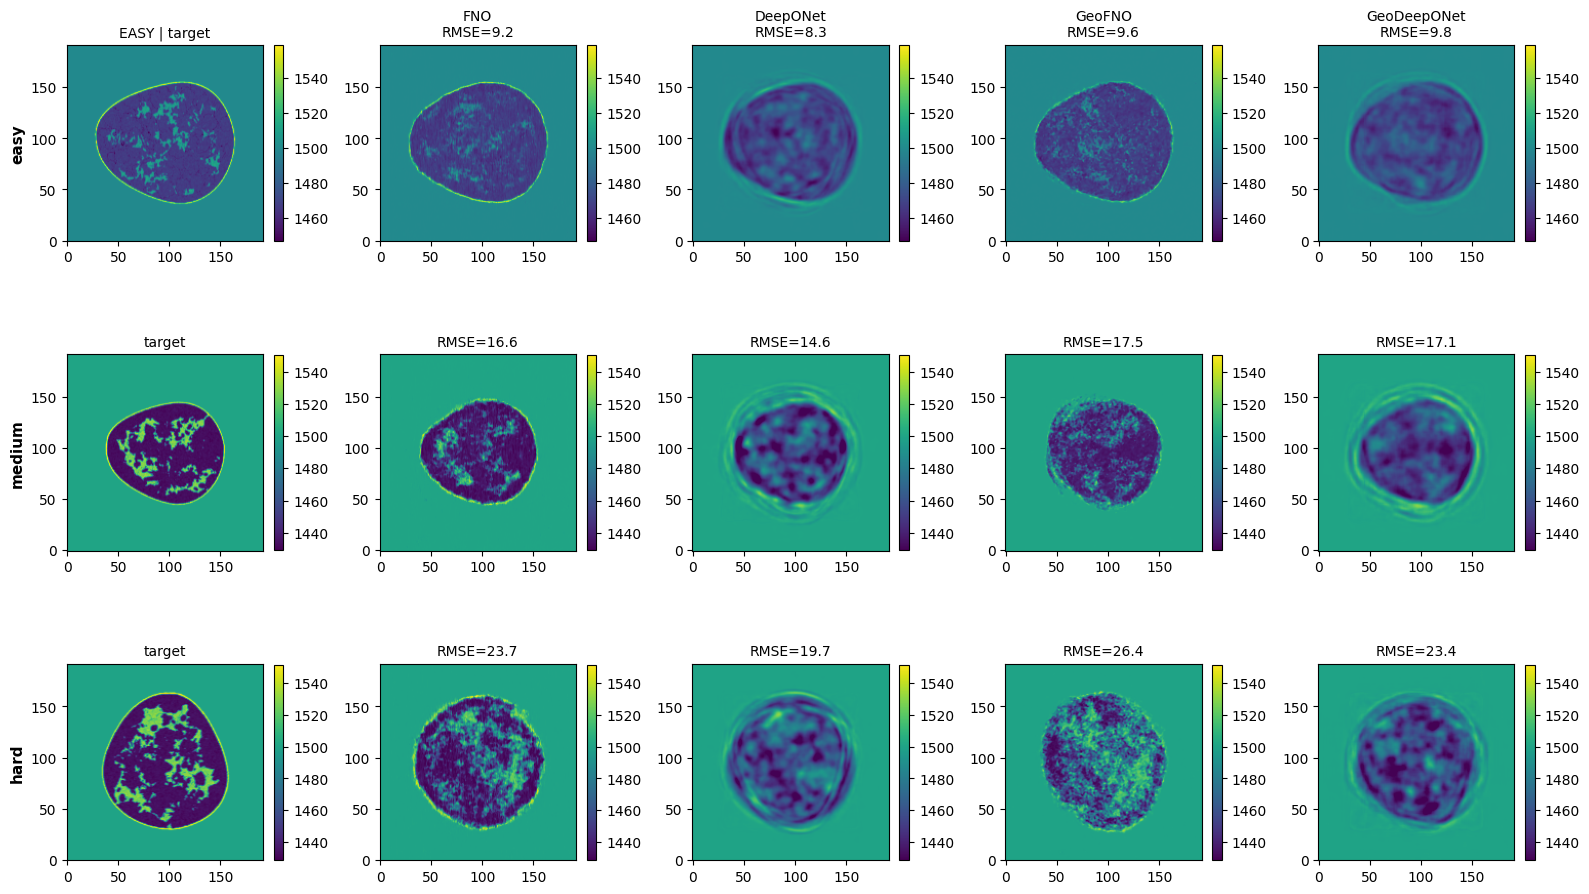

saved /workspace/reference_points/robustness_benchmark/visual_comparison_preds.png


In [20]:
def plot_visual_comparison():
    chosen = [("easy", easy_idx), ("medium", medium_idx), ("hard", hard_idx)]
    n_rows = len(chosen)
    n_cols = 1 + len(DISPLAY_MODELS)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))

    for row, (label, idx) in enumerate(chosen):
        sample = load_sample(test_files[idx], stats["c_min"], stats["c_max"], M_hom_complex)
        target = sample["c_phys"]
        vmin, vmax = target.min(), target.max()

        im = axes[row, 0].imshow(target, origin="lower", vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"{label.upper()} | target" if row == 0 else "target", fontsize=10)
        axes[row, 0].set_ylabel(label, fontsize=11, fontweight="bold")
        plt.colorbar(im, ax=axes[row, 0], fraction=0.045)

        for col, mname in enumerate(DISPLAY_MODELS, start=1):
            pred = predict_one(mname, sample["x_residual"])
            err = pred - target
            rmse_val = rmse(pred, target)
            im = axes[row, col].imshow(pred, origin="lower", vmin=vmin, vmax=vmax)
            title = f"{mname}" if row == 0 else ""
            axes[row, col].set_title(f"{title}\nRMSE={rmse_val:.1f}".strip(), fontsize=10)
            plt.colorbar(im, ax=axes[row, col], fraction=0.045)

    plt.tight_layout()
    out_path = OUT_DIR / "visual_comparison_preds.png"
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved {out_path}")

plot_visual_comparison()

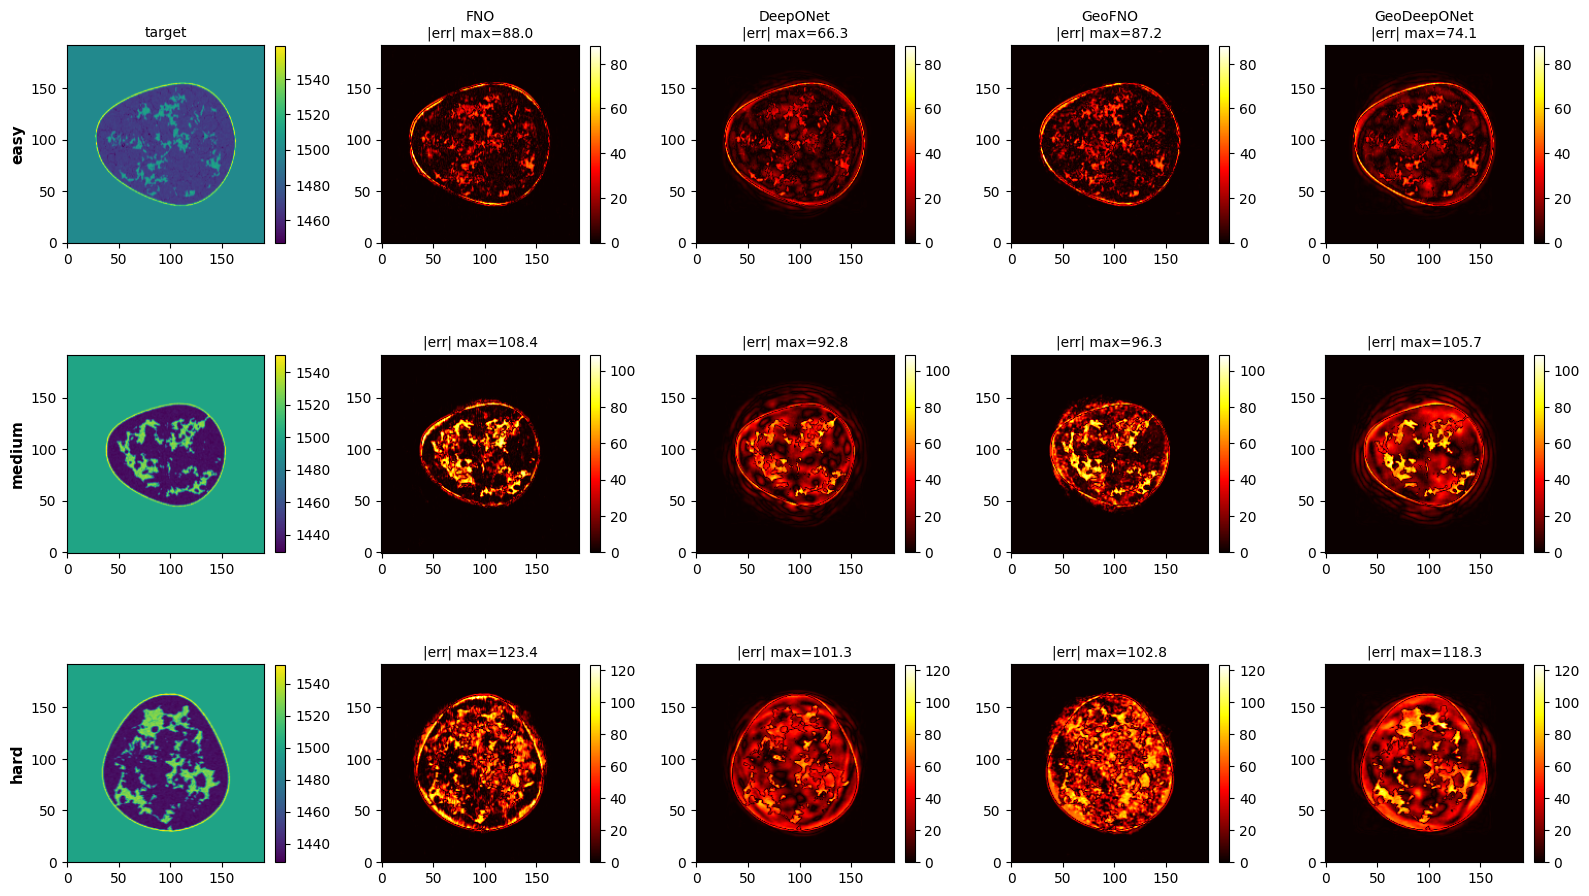

saved /workspace/reference_points/robustness_benchmark/visual_comparison_errors.png


In [21]:
def plot_visual_errors():
    """Same but with absolute-error maps instead of predictions."""
    chosen = [("easy", easy_idx), ("medium", medium_idx), ("hard", hard_idx)]
    n_rows = len(chosen)
    n_cols = 1 + len(DISPLAY_MODELS)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))

    for row, (label, idx) in enumerate(chosen):
        sample = load_sample(test_files[idx], stats["c_min"], stats["c_max"], M_hom_complex)
        target = sample["c_phys"]

        # First col: target
        im = axes[row, 0].imshow(target, origin="lower")
        axes[row, 0].set_title("target" if row == 0 else "", fontsize=10)
        axes[row, 0].set_ylabel(label, fontsize=11, fontweight="bold")
        plt.colorbar(im, ax=axes[row, 0], fraction=0.045)

        # Compute errors for max-scaling
        errs = {}
        for mname in DISPLAY_MODELS:
            pred = predict_one(mname, sample["x_residual"])
            errs[mname] = np.abs(pred - target)
        emax = max(e.max() for e in errs.values())

        for col, mname in enumerate(DISPLAY_MODELS, start=1):
            im = axes[row, col].imshow(errs[mname], origin="lower",
                                        cmap="hot", vmin=0, vmax=emax)
            title = f"{mname}" if row == 0 else ""
            axes[row, col].set_title(f"{title}\n|err| max={errs[mname].max():.1f}".strip(), fontsize=10)
            plt.colorbar(im, ax=axes[row, col], fraction=0.045)

    plt.tight_layout()
    out_path = OUT_DIR / "visual_comparison_errors.png"
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved {out_path}")

plot_visual_errors()

## 6. Sensor permutation robustness

Главное практическое свойство Geo-моделей: точная инвариантность к перестановке
индексов источников и приёмников. Geo-модели должны давать **тот же** ответ
после permutation, не-Geo разваливаются.

Эксперимент: для разных perm_kind / k оцениваем RMSE на test (или подвыборке
для скорости).

In [22]:
# Use a subset of test for speed during sweeps (full eval is in main_results)
PERM_TEST_SUBSET = test_files[:200]
print(f"Permutation sweeps use {len(PERM_TEST_SUBSET)} test samples for speed")

def apply_perm(x_residual_np, perm_idx, axis):
    """Apply permutation to receiver or source axis of x_residual.
    x_residual: (2, S, R). axis="receiver" permutes R, axis="source" permutes S.
    """
    if axis == "receiver":
        return x_residual_np[:, :, perm_idx]
    elif axis == "source":
        return x_residual_np[:, perm_idx, :]
    raise ValueError(axis)


def get_perm(perm_kind, N, k=0):
    if perm_kind == "shift":
        return np.roll(np.arange(N), k)
    elif perm_kind == "random":
        rng = np.random.RandomState(SEED + k)
        return rng.permutation(N)
    raise ValueError(perm_kind)


def evaluate_with_perm(model_name, files, perm_axis, perm_kind, k):
    """Evaluate one model under a given permutation of receivers or sources.

    The permutation is applied jointly to:
      - x_residual axis (R or S)
      - rcv_norm / src_norm
      - rcv_pixel (for receiver perm)
    so that geometry remains physically consistent.
    """
    N = R if perm_axis == "receiver" else S
    perm_idx = get_perm(perm_kind, N, k)
    perm_t = torch.from_numpy(perm_idx).long().to(device)

    if perm_axis == "receiver":
        rcv_norm_p = rcv_norm_t[perm_t]
        rcv_pixel_p = rcv_pixel_t[perm_t]
        src_norm_p = src_norm_t
    else:
        rcv_norm_p = rcv_norm_t
        rcv_pixel_p = rcv_pixel_t
        src_norm_p = src_norm_t[perm_t]

    rows = []
    data_range = stats["c_max"] - stats["c_min"]
    for fp in files:
        sample = load_sample(fp, stats["c_min"], stats["c_max"], M_hom_complex)
        x_perm = apply_perm(sample["x_residual"], perm_idx, perm_axis)
        pred = predict_one(model_name, x_perm,
                           src_norm=src_norm_p, rcv_norm=rcv_norm_p,
                           rcv_pixel=rcv_pixel_p)
        target = sample["c_phys"]
        rows.append({"rmse": rmse(pred, target),
                     "psnr": psnr(pred, target, data_range)})
    return rows

Permutation sweeps use 200 test samples for speed


In [23]:
# === Receiver permutation sweep ===
RECEIVER_PERM_PARAMS = [
    ("identity", "shift", 0),
    ("shift k=1", "shift", 1),
    ("shift k=2", "shift", 2),
    ("shift k=4", "shift", 4),
    ("shift k=8", "shift", 8),
    ("shift k=16", "shift", 16),
    ("shift k=37", "shift", 37),
    ("shift k=64", "shift", 64),
    ("random",   "random", 0),
]

print("=== Receiver permutation sweep ===\n")
print(f"  {'permutation':<15}" + "".join(f"{m:>14}" for m in MODEL_ORDER))
print("  " + "-" * (15 + 14 * len(MODEL_ORDER)))

receiver_perm_results = {label: {} for label, _, _ in RECEIVER_PERM_PARAMS}
for label, kind, k in RECEIVER_PERM_PARAMS:
    row = f"  {label:<15}"
    for name in MODEL_ORDER:
        rows_ = evaluate_with_perm(name, PERM_TEST_SUBSET, "receiver", kind, k)
        rmse_mean = float(np.mean([r["rmse"] for r in rows_]))
        receiver_perm_results[label][name] = rmse_mean
        row += f"{rmse_mean:>14.2f}"
    print(row)

=== Receiver permutation sweep ===

  permutation             U-Net           FNO      DeepONet       GeoUNet        GeoFNO   GeoDeepONetGeoDeepONet-v2GeoDeepONet-PMA
  -------------------------------------------------------------------------------------------------------------------------------
  identity                18.91         16.46         14.41         19.23         17.94         17.57         17.85         17.54
  shift k=1               19.25         18.62         19.76         19.23         17.94         17.57         17.85         17.54
  shift k=2               19.38         21.21         20.94         19.23         17.94         17.57         17.85         17.54
  shift k=4               19.32         18.21         21.30         19.23         17.94         17.57         17.85         17.54
  shift k=8               19.73         19.97         22.72         19.23         17.94         17.57         17.85         17.54
  shift k=16              20.79         22.09        

In [24]:
# === Source permutation sweep ===
SOURCE_PERM_PARAMS = [
    ("identity", "shift", 0),
    ("shift k=1", "shift", 1),
    ("shift k=2", "shift", 2),
    ("shift k=4", "shift", 4),
    ("random",   "random", 0),
]

print("=== Source permutation sweep ===\n")
print(f"  {'permutation':<15}" + "".join(f"{m:>14}" for m in MODEL_ORDER))
print("  " + "-" * (15 + 14 * len(MODEL_ORDER)))

source_perm_results = {label: {} for label, _, _ in SOURCE_PERM_PARAMS}
for label, kind, k in SOURCE_PERM_PARAMS:
    row = f"  {label:<15}"
    for name in MODEL_ORDER:
        rows_ = evaluate_with_perm(name, PERM_TEST_SUBSET, "source", kind, k)
        rmse_mean = float(np.mean([r["rmse"] for r in rows_]))
        source_perm_results[label][name] = rmse_mean
        row += f"{rmse_mean:>14.2f}"
    print(row)

=== Source permutation sweep ===

  permutation             U-Net           FNO      DeepONet       GeoUNet        GeoFNO   GeoDeepONetGeoDeepONet-v2GeoDeepONet-PMA
  -------------------------------------------------------------------------------------------------------------------------------
  identity                18.91         16.46         14.41         19.23         17.94         17.57         17.85         17.54
  shift k=1               20.23         22.10         22.85         19.23         17.94         17.57         17.85         17.54
  shift k=2               22.24         24.04         23.58         19.23         17.94         17.57         17.85         17.54
  shift k=4               25.38         26.39         23.66         19.23         17.94         17.57         17.85         17.54
  random                  23.07         28.05         20.93         19.23         17.94         17.57         17.85         17.54


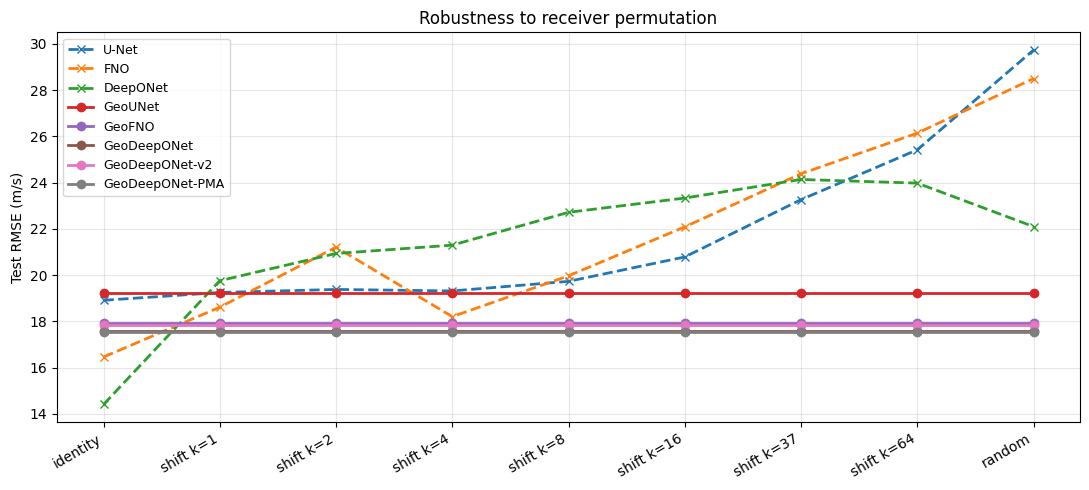

saved /workspace/reference_points/robustness_benchmark/receiver_perm_robustness.png


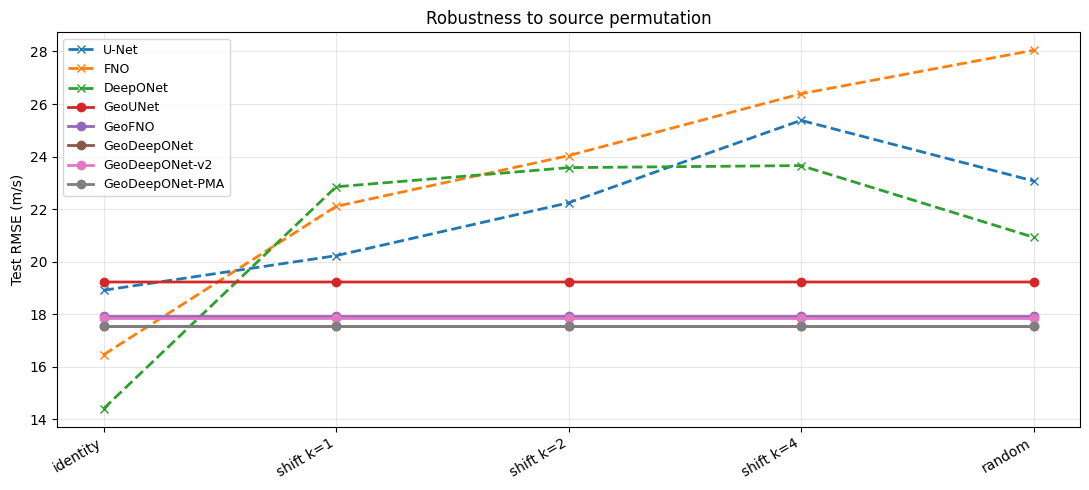

saved /workspace/reference_points/robustness_benchmark/source_perm_robustness.png


In [25]:
def plot_perm_results(perm_results, perm_axis_label, out_name):
    labels = list(perm_results.keys())
    n_models = len(MODEL_ORDER)
    xs = np.arange(len(labels))
    width = 0.85 / n_models

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, name in enumerate(MODEL_ORDER):
        vals = [perm_results[lab][name] for lab in labels]
        offset = (i - (n_models - 1) / 2) * width
        marker = "o" if is_geo(name) else "x"
        ls = "-" if is_geo(name) else "--"
        ax.plot(xs, vals, marker=marker, linestyle=ls, label=name, linewidth=2)

    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Test RMSE (m/s)")
    ax.set_title(f"Robustness to {perm_axis_label} permutation")
    ax.legend(fontsize=9, loc="best")
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    out_path = OUT_DIR / out_name
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved {out_path}")


plot_perm_results(receiver_perm_results, "receiver", "receiver_perm_robustness.png")
plot_perm_results(source_perm_results, "source", "source_perm_robustness.png")

## 7. Sensor subsampling — number of receivers

**Главный практический аргумент в пользу Geo-моделей.** Geo-модели с
per-token MLP работают с **любым** числом приёмников без переобучения. Не-Geo
модели имеют фиксированную размерность входа `(2, 16, 256)` и не могут
работать на R≠256 нативно.

Для не-Geo моделей делаем **zero-out trick** — заменяем «отсутствующие»
приёмники нулями в 256-векторе. Это **другая задача** (inpainting), но даёт
сравнимую цифру.

In [26]:
SUBSAMPLE_R_VALUES = [256, 192, 128, 96, 64, 32]
print("Subsampling receiver values:", SUBSAMPLE_R_VALUES)
print("Geo-models: native subsampling (only kept receivers go into per-token MLP)")
print("Non-Geo: zero-out trick (kept receivers values are normal, rest are zeros)\n")

# Sample which receivers to keep, deterministic
def sample_kept_receivers(R_keep, seed=42):
    rng = np.random.RandomState(seed)
    if R_keep >= R:
        return np.arange(R)
    return np.sort(rng.choice(R, size=R_keep, replace=False))


def evaluate_subsample_R(model_name, files, R_keep):
    """For Geo-models: only use the kept receivers (native).
    For non-Geo: zero out the not-kept receivers (zero-out trick)."""
    keep_idx = sample_kept_receivers(R_keep)
    keep_t = torch.from_numpy(keep_idx).long().to(device)
    mask_np = np.zeros(R, dtype=np.float32)
    mask_np[keep_idx] = 1.0

    is_g = is_geo(model_name)

    if is_g:
        # Use only kept receivers — works because per-token MLP is set-based
        rcv_norm_p = rcv_norm_t[keep_t]
        rcv_pixel_p = rcv_pixel_t[keep_t]
        src_norm_p = src_norm_t

    rows = []
    for fp in files:
        sample = load_sample(fp, stats["c_min"], stats["c_max"], M_hom_complex)
        x_full = sample["x_residual"]            # (2, S, R)

        if is_g:
            x_used = x_full[:, :, keep_idx]      # (2, S, R_keep)
            pred = predict_one(model_name, x_used,
                               src_norm=src_norm_p, rcv_norm=rcv_norm_p,
                               rcv_pixel=rcv_pixel_p)
        else:
            # Zero-out trick: keep tensor at full size, mask the rest
            x_masked = x_full * mask_np[None, None, :]
            pred = predict_one(model_name, x_masked)

        rows.append({"rmse": rmse(pred, sample["c_phys"])})
    return rows


print("=== Receiver subsampling ===")
print(f"  {'R_keep':<8}" + "".join(f"{m:>14}" for m in MODEL_ORDER))
print("  " + "-" * (8 + 14 * len(MODEL_ORDER)))

receiver_subsample_results = {R_k: {} for R_k in SUBSAMPLE_R_VALUES}
for R_keep in SUBSAMPLE_R_VALUES:
    row = f"  {R_keep:<8}"
    for name in MODEL_ORDER:
        rows_ = evaluate_subsample_R(name, PERM_TEST_SUBSET, R_keep)
        rmse_mean = float(np.mean([r["rmse"] for r in rows_]))
        receiver_subsample_results[R_keep][name] = rmse_mean
        row += f"{rmse_mean:>14.2f}"
    print(row)

Subsampling receiver values: [256, 192, 128, 96, 64, 32]
Geo-models: native subsampling (only kept receivers go into per-token MLP)
Non-Geo: zero-out trick (kept receivers values are normal, rest are zeros)

=== Receiver subsampling ===
  R_keep           U-Net           FNO      DeepONet       GeoUNet        GeoFNO   GeoDeepONetGeoDeepONet-v2GeoDeepONet-PMA
  ------------------------------------------------------------------------------------------------------------------------
  256              18.91         16.46         14.41         19.23         17.94         17.57         17.85         17.54
  192              20.86         19.59         15.30         20.51         19.27         17.95         18.94         17.77
  128              23.83         25.36         16.41         22.89         21.76         18.92         20.61         18.27
  96               24.35         27.60         17.41         23.26         22.58         19.32         20.76         18.79
  64               24.08

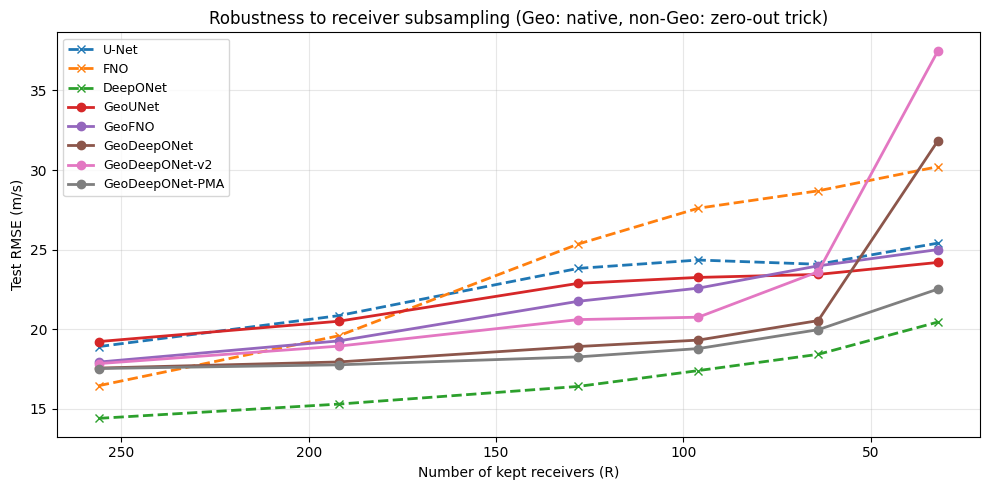

saved /workspace/reference_points/robustness_benchmark/receiver_subsampling.png


In [27]:
def plot_subsampling(results, x_values, x_label, out_name, title=""):
    fig, ax = plt.subplots(figsize=(10, 5))
    for name in MODEL_ORDER:
        vals = [results[v][name] for v in x_values]
        marker = "o" if is_geo(name) else "x"
        ls = "-" if is_geo(name) else "--"
        ax.plot(x_values, vals, marker=marker, linestyle=ls, label=name, linewidth=2)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Test RMSE (m/s)")
    if title:
        ax.set_title(title)
    ax.legend(fontsize=9, loc="best")
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    ax.invert_xaxis()   # fewer sensors → right side
    plt.tight_layout()
    out_path = OUT_DIR / out_name
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved {out_path}")


plot_subsampling(receiver_subsample_results, SUBSAMPLE_R_VALUES,
                 "Number of kept receivers (R)",
                 "receiver_subsampling.png",
                 title="Robustness to receiver subsampling "
                       "(Geo: native, non-Geo: zero-out trick)")

## 8. Source subsampling — number of sources

То же для источников: S = 16, 12, 8, 4.

=== Source subsampling ===
  S_keep           U-Net           FNO      DeepONet       GeoUNet        GeoFNO   GeoDeepONetGeoDeepONet-v2GeoDeepONet-PMA
  ------------------------------------------------------------------------------------------------------------------------
  16               18.91         16.46         14.41         19.23         17.94         17.57         17.85         17.54
  12               19.46         19.65         16.32         20.15         19.36         21.03         24.20         18.33
  8                22.73         24.16         18.59         21.56         20.87         20.15         24.37         19.42
  4                27.32         28.48         20.51         21.56         22.90         23.73         32.96         20.79


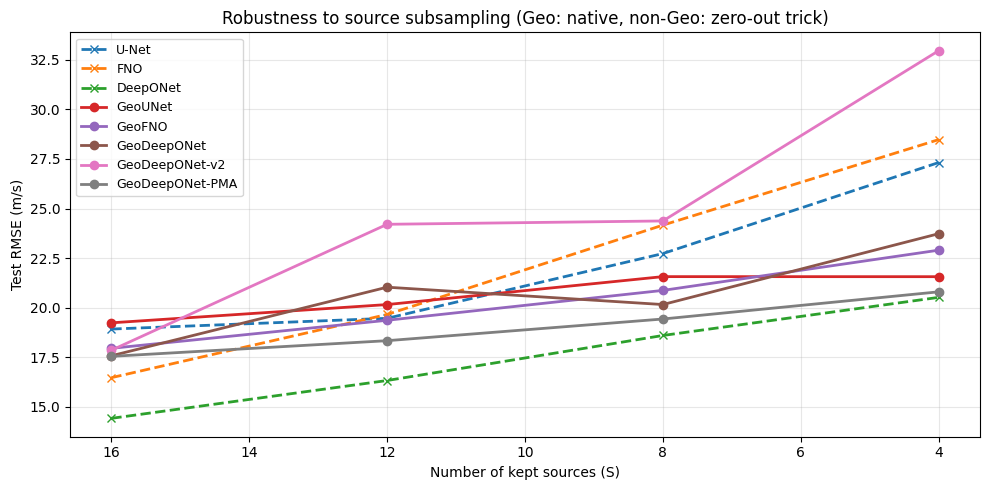

saved /workspace/reference_points/robustness_benchmark/source_subsampling.png


In [28]:
SUBSAMPLE_S_VALUES = [16, 12, 8, 4]

def sample_kept_sources(S_keep, seed=42):
    rng = np.random.RandomState(seed + 1000)
    if S_keep >= S:
        return np.arange(S)
    return np.sort(rng.choice(S, size=S_keep, replace=False))


def evaluate_subsample_S(model_name, files, S_keep):
    keep_idx = sample_kept_sources(S_keep)
    keep_t = torch.from_numpy(keep_idx).long().to(device)
    mask_np = np.zeros(S, dtype=np.float32)
    mask_np[keep_idx] = 1.0

    is_g = is_geo(model_name)

    if is_g:
        src_norm_p = src_norm_t[keep_t]
        rcv_norm_p = rcv_norm_t
        rcv_pixel_p = rcv_pixel_t

    rows = []
    for fp in files:
        sample = load_sample(fp, stats["c_min"], stats["c_max"], M_hom_complex)
        x_full = sample["x_residual"]
        if is_g:
            x_used = x_full[:, keep_idx, :]
            pred = predict_one(model_name, x_used,
                               src_norm=src_norm_p, rcv_norm=rcv_norm_p,
                               rcv_pixel=rcv_pixel_p)
        else:
            x_masked = x_full * mask_np[None, :, None]
            pred = predict_one(model_name, x_masked)
        rows.append({"rmse": rmse(pred, sample["c_phys"])})
    return rows


print("=== Source subsampling ===")
print(f"  {'S_keep':<8}" + "".join(f"{m:>14}" for m in MODEL_ORDER))
print("  " + "-" * (8 + 14 * len(MODEL_ORDER)))

source_subsample_results = {S_k: {} for S_k in SUBSAMPLE_S_VALUES}
for S_keep in SUBSAMPLE_S_VALUES:
    row = f"  {S_keep:<8}"
    for name in MODEL_ORDER:
        rows_ = evaluate_subsample_S(name, PERM_TEST_SUBSET, S_keep)
        rmse_mean = float(np.mean([r["rmse"] for r in rows_]))
        source_subsample_results[S_keep][name] = rmse_mean
        row += f"{rmse_mean:>14.2f}"
    print(row)

plot_subsampling(source_subsample_results, SUBSAMPLE_S_VALUES,
                 "Number of kept sources (S)",
                 "source_subsampling.png",
                 title="Robustness to source subsampling "
                       "(Geo: native, non-Geo: zero-out trick)")

## 9. Noise robustness

Добавляем гауссов шум к комплексной измерительной матрице `M`
**до** вычета `M_hom`. Уровни SNR: ∞ (no noise), 30, 20, 15, 10 dB.

SNR = 20 log10(||M|| / ||N||), где N — добавляемый комплексный шум.

In [29]:
NOISE_SNR_DB = [float("inf"), 30, 20, 15, 10]

def add_complex_noise(M_complex, snr_db):
    if not np.isfinite(snr_db):
        return M_complex
    signal_power = float(np.mean(np.abs(M_complex) ** 2))
    noise_power = signal_power / (10 ** (snr_db / 10.0))
    sigma = np.sqrt(noise_power / 2.0)   # complex noise: σ on Re and Im
    n_re = np.random.RandomState(42).randn(*M_complex.shape).astype(np.float32) * sigma
    n_im = np.random.RandomState(43).randn(*M_complex.shape).astype(np.float32) * sigma
    return M_complex + (n_re + 1j * n_im)


def load_sample_noisy(path, c_min, c_max, M_hom_c, snr_db, mask_hw=2):
    d = np.load(path)
    x_raw = d["x"].astype(np.float32)
    c = d["c"].astype(np.float32)
    src_ring = d["source_ring_idx"].astype(np.int64)
    M = x_raw[0] + 1j * x_raw[1]
    M = add_complex_noise(M, snr_db)
    M = M - M_hom_c
    if mask_hw > 0:
        M = mask_self_receivers(M, src_ring, half_width=mask_hw)
    x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)
    x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
    if x_scale < 1e-8:
        x_scale = 1.0
    x_tensor = x_tensor / x_scale
    return x_tensor, c


def evaluate_noise(model_name, files, snr_db):
    rows = []
    for fp in files:
        x_t, c = load_sample_noisy(fp, stats["c_min"], stats["c_max"],
                                     M_hom_complex, snr_db)
        pred = predict_one(model_name, x_t)
        rows.append({"rmse": rmse(pred, c)})
    return rows


print("=== Noise robustness ===")
print(f"  {'SNR (dB)':<10}" + "".join(f"{m:>14}" for m in MODEL_ORDER))
print("  " + "-" * (10 + 14 * len(MODEL_ORDER)))

noise_results = {}
for snr in NOISE_SNR_DB:
    snr_label = "clean" if not np.isfinite(snr) else f"{snr:.0f}"
    noise_results[snr_label] = {}
    row_str = f"  {snr_label:<10}"
    for name in MODEL_ORDER:
        rows_ = evaluate_noise(name, PERM_TEST_SUBSET, snr)
        rmse_mean = float(np.mean([r["rmse"] for r in rows_]))
        noise_results[snr_label][name] = rmse_mean
        row_str += f"{rmse_mean:>14.2f}"
    print(row_str)

=== Noise robustness ===
  SNR (dB)           U-Net           FNO      DeepONet       GeoUNet        GeoFNO   GeoDeepONetGeoDeepONet-v2GeoDeepONet-PMA
  --------------------------------------------------------------------------------------------------------------------------
  clean              18.91         16.46         14.41         19.23         17.94         17.57         17.85         17.54
  30                 20.58         17.28         14.83         19.69         18.63         19.65         19.98         18.23
  20                 29.35         24.52         17.39         24.56         23.14         27.30         26.62         26.13
  15                 29.83         27.90         19.40         26.88         24.67         28.22         28.10         28.46
  10                 30.08         28.58         20.79         27.85         25.15         28.64         28.81         29.22


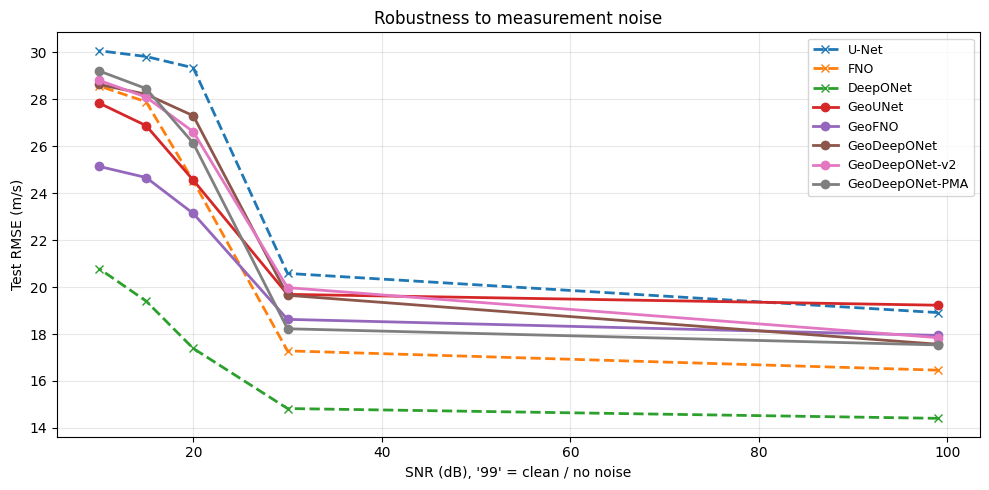

saved /workspace/reference_points/robustness_benchmark/noise_robustness.png


In [30]:
def plot_noise_results():
    snr_labels = list(noise_results.keys())
    x_vals = [99 if s == "clean" else int(s) for s in snr_labels]   # ∞ → 99 for plotting

    fig, ax = plt.subplots(figsize=(10, 5))
    for name in MODEL_ORDER:
        vals = [noise_results[s][name] for s in snr_labels]
        marker = "o" if is_geo(name) else "x"
        ls = "-" if is_geo(name) else "--"
        ax.plot(x_vals, vals, marker=marker, linestyle=ls, label=name, linewidth=2)

    ax.set_xlabel("SNR (dB), '99' = clean / no noise")
    ax.set_ylabel("Test RMSE (m/s)")
    ax.set_title("Robustness to measurement noise")
    ax.legend(fontsize=9, loc="best")
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    out_path = OUT_DIR / "noise_robustness.png"
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved {out_path}")

plot_noise_results()

## 10. Inference time benchmark

Wall-clock инференс для каждой модели, GPU, batch=1, усреднено по 50
прогонам после 5 warm-up прогонов.

Также прогоняем **j-Wave forward solver** один раз для сравнения — это
обычно занимает секунды, тогда как нейронная сеть — миллисекунды. Это
ключевая практическая мотивация использования нейронных операторов.

In [31]:
WARMUP = 5
N_RUNS = 50
print(f"Inference time: {N_RUNS} runs after {WARMUP} warmup, batch=1\n")

# Pick one test sample, build input tensors once
sample_demo = load_sample(test_files[0], stats["c_min"], stats["c_max"], M_hom_complex)
x_demo = torch.from_numpy(sample_demo["x_residual"]).unsqueeze(0).to(device)

time_results = {}
print(f"  {'Model':<16}{'mean ms':>12}{'std ms':>12}")
print("  " + "-" * 40)

for name in MODEL_ORDER:
    model = MODELS[name]["model"]

    # Warmup
    with torch.no_grad():
        for _ in range(WARMUP):
            if name == "U-Net" or name == "FNO":
                _ = model(x_demo)
            elif name == "DeepONet":
                _ = model(x_demo, coords_device)
            elif name in ("GeoUNet", "GeoFNO"):
                _ = model(x_demo, src_norm_t.unsqueeze(0), rcv_norm_t.unsqueeze(0),
                          rcv_pixel_t.unsqueeze(0))
            else:  # GeoDeepONet*
                _ = model(x_demo, src_norm_t.unsqueeze(0), rcv_norm_t.unsqueeze(0),
                          coords_device)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # Timed runs
    times = []
    with torch.no_grad():
        for _ in range(N_RUNS):
            t0 = time.perf_counter()
            if name == "U-Net" or name == "FNO":
                _ = model(x_demo)
            elif name == "DeepONet":
                _ = model(x_demo, coords_device)
            elif name in ("GeoUNet", "GeoFNO"):
                _ = model(x_demo, src_norm_t.unsqueeze(0), rcv_norm_t.unsqueeze(0),
                          rcv_pixel_t.unsqueeze(0))
            else:
                _ = model(x_demo, src_norm_t.unsqueeze(0), rcv_norm_t.unsqueeze(0),
                          coords_device)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)

    mean_ms = float(np.mean(times))
    std_ms = float(np.std(times))
    time_results[name] = {"mean_ms": mean_ms, "std_ms": std_ms,
                          "runs": times}
    print(f"  {name:<16}{mean_ms:>12.2f}{std_ms:>12.2f}")

# j-Wave forward (for comparison)
print("\nTiming j-Wave forward solver (one full pass S=16 sources)...")
# Quick warmup
_ = forward_measurements_full_jit(c_hom).block_until_ready()
jw_times = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = forward_measurements_full_jit(c_hom).block_until_ready()
    jw_times.append((time.perf_counter() - t0) * 1000)
jw_mean = float(np.mean(jw_times))
jw_std = float(np.std(jw_times))
print(f"  j-Wave forward     {jw_mean:>10.1f} ± {jw_std:.1f} ms")
print(f"\nNeural models ~{jw_mean / max(t['mean_ms'] for t in time_results.values()):.0f}× faster than j-Wave forward")

time_results["jWave_forward"] = {"mean_ms": jw_mean, "std_ms": jw_std}

Inference time: 50 runs after 5 warmup, batch=1

  Model                mean ms      std ms
  ----------------------------------------
  U-Net                   1.67        0.11
  FNO                     4.12        0.13
  DeepONet                0.87        0.01
  GeoUNet                 2.37        0.47
  GeoFNO                 17.86        0.05
  GeoDeepONet             0.72        0.05
  GeoDeepONet-v2          1.65        0.01
  GeoDeepONet-PMA         2.08        0.05

Timing j-Wave forward solver (one full pass S=16 sources)...
  j-Wave forward         1831.7 ± 17.8 ms

Neural models ~103× faster than j-Wave forward


/tmp/ipykernel_1097/1351865368.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


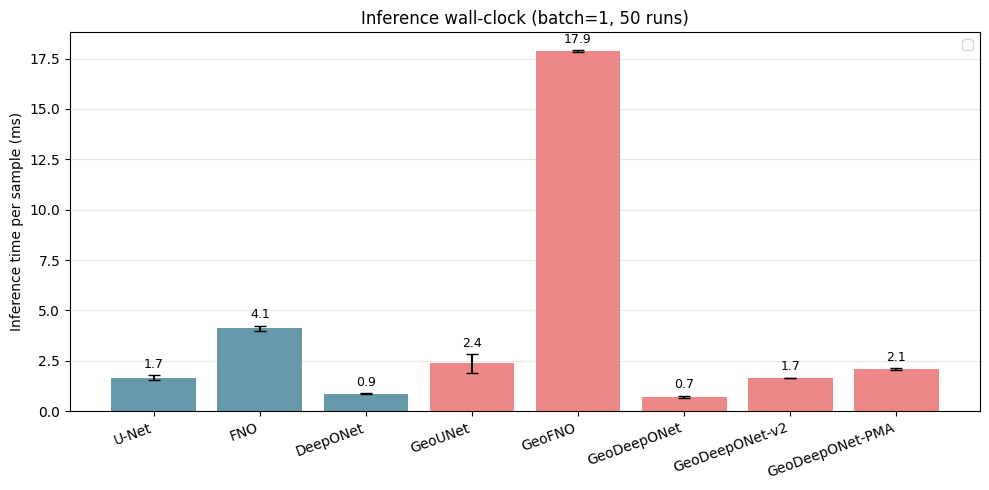

saved /workspace/reference_points/robustness_benchmark/inference_time.png


In [32]:
def plot_inference_time():
    names = [n for n in MODEL_ORDER]
    means = [time_results[n]["mean_ms"] for n in names]
    stds = [time_results[n]["std_ms"] for n in names]
    colors = ["#69a" if not is_geo(n) else "#e88" for n in names]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(names, means, yerr=stds, color=colors, capsize=4)

    # j-Wave as a horizontal line
    # ax.axhline(time_results["jWave_forward"]["mean_ms"], color="black",
    #             linestyle=":", linewidth=2,
    #             label=f"j-Wave forward ({time_results['jWave_forward']['mean_ms']:.0f} ms)")

    ax.set_ylabel("Inference time per sample (ms)")
    ax.set_title(f"Inference wall-clock (batch=1, {N_RUNS} runs)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    plt.xticks(rotation=20, ha="right")

    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + max(means) * 0.02, f"{m:.1f}",
                ha="center", fontsize=9)

    plt.tight_layout()
    out_path = OUT_DIR / "inference_time.png"
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved {out_path}")

plot_inference_time()

## 11. Numerical invariance check (per-model)

Точная численная проверка инвариантности. Для каждой модели прогоняем
forward на одном тестовом сэмпле, потом на сэмпле с переставленными
приёмниками + соответствующей геометрией, и сравниваем выходы. Geo-модели
должны давать `max |y0 - y1| < 1e-6`, не-Geo — заметную разницу.

In [33]:
def numerical_invariance_check(name, sample, perm_axis, perm_kind, k=4):
    N = R if perm_axis == "receiver" else S
    perm_idx = get_perm(perm_kind, N, k)
    perm_t = torch.from_numpy(perm_idx).long().to(device)

    if perm_axis == "receiver":
        rcv_norm_p = rcv_norm_t[perm_t]
        rcv_pixel_p = rcv_pixel_t[perm_t]
        src_norm_p = src_norm_t
    else:
        rcv_norm_p = rcv_norm_t
        rcv_pixel_p = rcv_pixel_t
        src_norm_p = src_norm_t[perm_t]

    y0 = predict_one(name, sample["x_residual"])
    y1 = predict_one(name, apply_perm(sample["x_residual"], perm_idx, perm_axis),
                     src_norm=src_norm_p, rcv_norm=rcv_norm_p, rcv_pixel=rcv_pixel_p)
    return float(np.abs(y0 - y1).max()), float(np.abs(y0 - y1).max() / max(np.abs(y0).max(), 1e-9))


sample_inv = load_sample(test_files[0], stats["c_min"], stats["c_max"], M_hom_complex)

print("=== Numerical invariance check on one test sample ===\n")
print(f"  {'Model':<16}"
      f"{'rcv shift k=4':>16}{'rcv random':>16}{'src shift k=3':>16}{'src random':>16}")
print("  " + "-" * (16 + 16 * 4))

invariance_table = {}
for name in MODEL_ORDER:
    rcv_shift = numerical_invariance_check(name, sample_inv, "receiver", "shift", 4)[0]
    rcv_rand = numerical_invariance_check(name, sample_inv, "receiver", "random", 4)[0]
    src_shift = numerical_invariance_check(name, sample_inv, "source", "shift", 3)[0]
    src_rand = numerical_invariance_check(name, sample_inv, "source", "random", 4)[0]
    invariance_table[name] = {
        "rcv_shift": rcv_shift, "rcv_random": rcv_rand,
        "src_shift": src_shift, "src_random": src_rand,
    }
    print(f"  {name:<16}{rcv_shift:>16.2e}{rcv_rand:>16.2e}{src_shift:>16.2e}{src_rand:>16.2e}")

print("\n  Geo-models should be ~1e-7. Non-Geo will show ~0.1 to ~1.0 — full reconstruction differs.")

=== Numerical invariance check on one test sample ===

  Model              rcv shift k=4      rcv random   src shift k=3      src random
  --------------------------------------------------------------------------------
  U-Net                   1.05e+02        1.15e+02        1.08e+02        1.07e+02
  FNO                     1.05e+02        1.07e+02        1.06e+02        1.04e+02
  DeepONet                8.34e+01        8.47e+01        9.48e+01        8.72e+01
  GeoUNet                 0.00e+00        0.00e+00        3.75e-01        2.98e-01
  GeoFNO                  0.00e+00        0.00e+00        2.26e-02        2.26e-02
  GeoDeepONet             1.22e-04        1.22e-04        1.22e-04        1.22e-04
  GeoDeepONet-v2          1.22e-04        1.22e-04        1.22e-04        1.22e-04
  GeoDeepONet-PMA         1.22e-04        1.22e-04        1.22e-04        1.22e-04

  Geo-models should be ~1e-7. Non-Geo will show ~0.1 to ~1.0 — full reconstruction differs.


## 12. Save all artifacts

Всё в одном словаре + папке. Этот JSON можно загружать прямо в
LaTeX-таблицу через pandas, и графики уже PNG-fit для презентации.

In [34]:
artifacts = {
    "main_results": {
        name: {
            "params": r["params"],
            "best_epoch": r["best_epoch"],
            "train": r["train"], "val": r["val"], "test": r["test"],
        }
        for name, r in main_results.items()
    },
    "receiver_perm":      receiver_perm_results,
    "source_perm":        source_perm_results,
    "receiver_subsample": receiver_subsample_results,
    "source_subsample":   source_subsample_results,
    "noise":              noise_results,
    "inference_time":     {k: {kk: vv for kk, vv in v.items() if kk != "runs"}
                            for k, v in time_results.items()},
    "invariance":         invariance_table,
    "models_order":       MODEL_ORDER,
    "display_models":     DISPLAY_MODELS,
    "sample_indices":     {"easy": int(easy_idx),
                            "medium": int(medium_idx),
                            "hard": int(hard_idx)},
}

with open(OUT_DIR / "all_results.json", "w", encoding="utf-8") as f:
    json.dump(artifacts, f, ensure_ascii=False, indent=2)

print(f"All artifacts saved to {OUT_DIR}")
print("\nFiles:")
for p in sorted(OUT_DIR.glob("*")):
    print(f"  {p.name}")

All artifacts saved to /workspace/reference_points/robustness_benchmark

Files:
  all_results.json
  inference_time.png
  main_table.csv
  noise_robustness.png
  receiver_perm_robustness.png
  receiver_subsampling.png
  source_perm_robustness.png
  source_subsampling.png
  visual_comparison_errors.png
  visual_comparison_preds.png


In [35]:
# === 25d: дополнительные возмущения — phase jitter, sector dropout, receiver shift ===
# Опирается на уже определённые в 25c: MODELS, MODEL_ORDER, predict_one, rmse,
# M_hom_complex, mask_self_receivers, src_norm_t/rcv_norm_t/rcv_pixel_t,
# PERM_TEST_SUBSET, is_geo, S, R.

def load_raw_M(path):
    """Сырое комплексное M (S, R), цель c (H, W), индексы источников."""
    d = np.load(path)
    x_raw = d["x"].astype(np.float32)
    c = d["c"].astype(np.float32)
    src_ring = d["source_ring_idx"].astype(np.int64)
    M = x_raw[0] + 1j * x_raw[1]
    return M, c, src_ring


def finalize_sample(M, src_ring, mask_hw=2):
    """Повтор предобработки 25c: residual → mask → percentile-norm.
    Возвращает нормированный (2, S, R) тензор. Нормировка per-sample, поэтому
    stats модели здесь не нужны (они применяются только при денормализации в predict_one)."""
    M = M - M_hom_complex
    if mask_hw > 0:
        M = mask_self_receivers(M, src_ring, half_width=mask_hw)
    x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)
    x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
    if x_scale < 1e-8:
        x_scale = 1.0
    return (x_tensor / x_scale).astype(np.float32)


def perturb_phase_jitter(M, sigma, rng):
    """M *= exp(i·φ), φ ~ N(0, σ²)."""
    if sigma <= 0:
        return M
    phi = rng.normal(0.0, sigma, size=M.shape).astype(np.float64)
    return M * np.exp(1j * phi)


def perturb_sector_dropout(M, fraction, rng):
    """Обнуление смежного углового сектора приёмников; fraction — доля кольца."""
    if fraction <= 0:
        return M
    Rl = M.shape[1]
    width = int(round(fraction * Rl))
    if width <= 0:
        return M
    start = rng.randint(0, Rl)
    idx = [(start + d) % Rl for d in range(width)]
    M = M.copy()
    M[:, idx] = 0.0 + 0.0j
    return M


def perturb_receiver_shift(M, k):
    """Циклический сдвиг столбцов (приёмников) на k."""
    if k == 0:
        return M
    return np.roll(M, shift=k, axis=1)

print("25d perturbation helpers defined")

25d perturbation helpers defined


In [36]:
# Baselines без возмущения на той же подвыборке, что и основные sweeps в 25c
print("=== 25d baselines (no perturbation) ===\n")
baseline_rmse_25d = {}
for name in MODEL_ORDER:
    errs = []
    for fp in PERM_TEST_SUBSET:
        M, c, src_ring = load_raw_M(fp)
        x = finalize_sample(M, src_ring)
        errs.append(rmse(predict_one(name, x), c))
    baseline_rmse_25d[name] = float(np.mean(errs))
    print(f"  {name:<16} baseline RMSE = {baseline_rmse_25d[name]:.2f}")


def run_sweep_25d(perturb_fn, levels, level_name, geo_shift_fn=None, seed=SEED):
    """perturb_fn(M, level, rng) -> возмущённое M.
    geo_shift_fn(level) -> (src_norm, rcv_norm, rcv_pixel) для Geo при receiver shift."""
    results = {lv: {} for lv in levels}
    print(f"\n  {level_name:<12}" + "".join(f"{m:>16}" for m in MODEL_ORDER))
    print("  " + "-" * (12 + 16 * len(MODEL_ORDER)))
    for lv in levels:
        row = f"  {str(lv):<12}"
        if geo_shift_fn is not None:
            sn, rn, rp = geo_shift_fn(lv)
        else:
            sn = rn = rp = None
        for name in MODEL_ORDER:
            rng = np.random.RandomState(seed)   # одинаковая реализация шума для всех моделей
            errs = []
            for fp in PERM_TEST_SUBSET:
                M, c, src_ring = load_raw_M(fp)
                Mp = perturb_fn(M, lv, rng)
                x = finalize_sample(Mp, src_ring)
                if geo_shift_fn is not None and is_geo(name):
                    pred = predict_one(name, x, src_norm=sn, rcv_norm=rn, rcv_pixel=rp)
                else:
                    pred = predict_one(name, x)
                errs.append(rmse(pred, c))
            results[lv][name] = float(np.mean(errs))
            row += f"{results[lv][name]:>16.2f}"
        print(row)
    return results


def degradation_25d(results, levels):
    deg = {lv: {} for lv in levels}
    for lv in levels:
        for name in MODEL_ORDER:
            b = baseline_rmse_25d[name]
            deg[lv][name] = 100.0 * (results[lv][name] - b) / b
    return deg


def print_deg_25d(deg, levels, level_name):
    print(f"\n  {level_name:<12}" + "".join(f"{m:>16}" for m in MODEL_ORDER))
    for lv in levels:
        row = f"  {str(lv):<12}"
        for name in MODEL_ORDER:
            row += f"{deg[lv][name]:>+15.1f}%"
        print(row)

=== 25d baselines (no perturbation) ===

  U-Net            baseline RMSE = 18.91
  FNO              baseline RMSE = 16.46
  DeepONet         baseline RMSE = 14.41
  GeoUNet          baseline RMSE = 19.23
  GeoFNO           baseline RMSE = 17.94
  GeoDeepONet      baseline RMSE = 17.57
  GeoDeepONet-v2   baseline RMSE = 17.85
  GeoDeepONet-PMA  baseline RMSE = 17.54


In [37]:
PHASE_LEVELS = [0.0, 0.1, 0.2, 0.3]
print("=== Phase jitter (RMSE) ===")
phase_results = run_sweep_25d(perturb_phase_jitter, PHASE_LEVELS, "sigma")
phase_deg = degradation_25d(phase_results, PHASE_LEVELS)
print("\n=== Phase jitter (деградация %) ===")
print_deg_25d(phase_deg, PHASE_LEVELS, "sigma")

=== Phase jitter (RMSE) ===

  sigma                  U-Net             FNO        DeepONet         GeoUNet          GeoFNO     GeoDeepONet  GeoDeepONet-v2 GeoDeepONet-PMA
  --------------------------------------------------------------------------------------------------------------------------------------------
  0.0                    18.91           16.46           14.41           19.23           17.94           17.57           17.85           17.54
  0.1                    19.60           16.61           14.51           19.42           18.03           18.35           18.49           18.24
  0.2                    21.88           17.10           14.80           20.24           18.51           21.28           20.94           20.98
  0.3                    24.65           18.08           15.21           21.66           19.56           22.93           22.81           23.64

=== Phase jitter (деградация %) ===

  sigma                  U-Net             FNO        DeepONet         GeoU

In [38]:
SECTOR_LEVELS = [0.0, 0.1, 0.2, 0.3]
print("=== Sector dropout (RMSE) ===")
sector_results = run_sweep_25d(perturb_sector_dropout, SECTOR_LEVELS, "fraction")
sector_deg = degradation_25d(sector_results, SECTOR_LEVELS)
print("\n=== Sector dropout (деградация %) ===")
print_deg_25d(sector_deg, SECTOR_LEVELS, "fraction")

=== Sector dropout (RMSE) ===

  fraction               U-Net             FNO        DeepONet         GeoUNet          GeoFNO     GeoDeepONet  GeoDeepONet-v2 GeoDeepONet-PMA
  --------------------------------------------------------------------------------------------------------------------------------------------
  0.0                    18.91           16.46           14.41           19.23           17.94           17.57           17.85           17.54
  0.1                    20.74           17.59           14.98           21.01           19.65           21.02           21.70           22.71
  0.2                    22.73           19.34           15.65           23.44           20.94           28.14           28.58           23.77
  0.3                    24.67           21.02           16.45           24.97           22.16           32.78           32.28           24.23

=== Sector dropout (деградация %) ===

  fraction               U-Net             FNO        DeepONet         

In [39]:
SHIFT_LEVELS = [0, 4, 8, 16, 32]

def geo_shift_fn(k):
    """Геометрические тензоры со сдвинутой осью приёмников на k."""
    if k == 0:
        return src_norm_t, rcv_norm_t, rcv_pixel_t
    idx = np.roll(np.arange(R), shift=k)
    idx_t = torch.from_numpy(idx).long().to(device)
    return src_norm_t, rcv_norm_t[idx_t], rcv_pixel_t[idx_t]

print("=== Receiver shift (RMSE) ===")
shift_results = run_sweep_25d(
    lambda M, k, rng: perturb_receiver_shift(M, k),
    SHIFT_LEVELS, "shift k", geo_shift_fn=geo_shift_fn,
)
shift_deg = degradation_25d(shift_results, SHIFT_LEVELS)
print("\n=== Receiver shift (деградация %) ===")
print_deg_25d(shift_deg, SHIFT_LEVELS, "shift k")

=== Receiver shift (RMSE) ===

  shift k                U-Net             FNO        DeepONet         GeoUNet          GeoFNO     GeoDeepONet  GeoDeepONet-v2 GeoDeepONet-PMA
  --------------------------------------------------------------------------------------------------------------------------------------------
  0                      18.91           16.46           14.41           19.23           17.94           17.57           17.85           17.54
  4                      32.59           30.80           52.65           24.25           24.23           36.77           38.08           28.64
  8                      31.14           30.90           44.15           24.48           24.23           36.82           37.98           28.68
  16                     31.47           30.49           45.04           24.22           24.26           37.63           38.28           28.48
  32                     31.05           30.40           44.85           24.33           24.26           36.94 

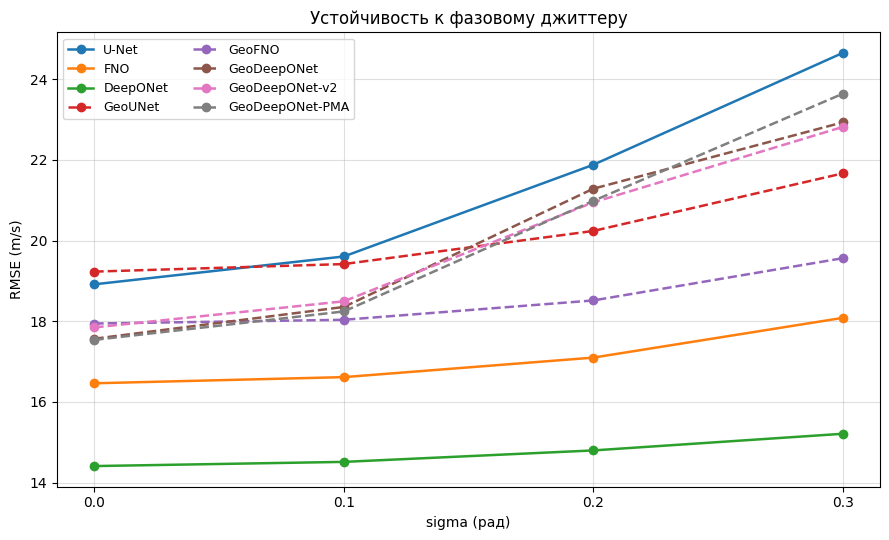

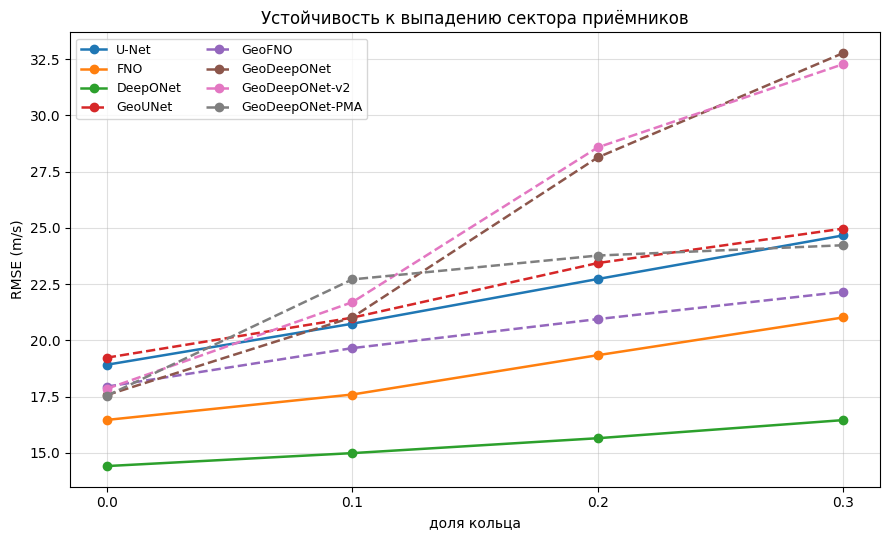

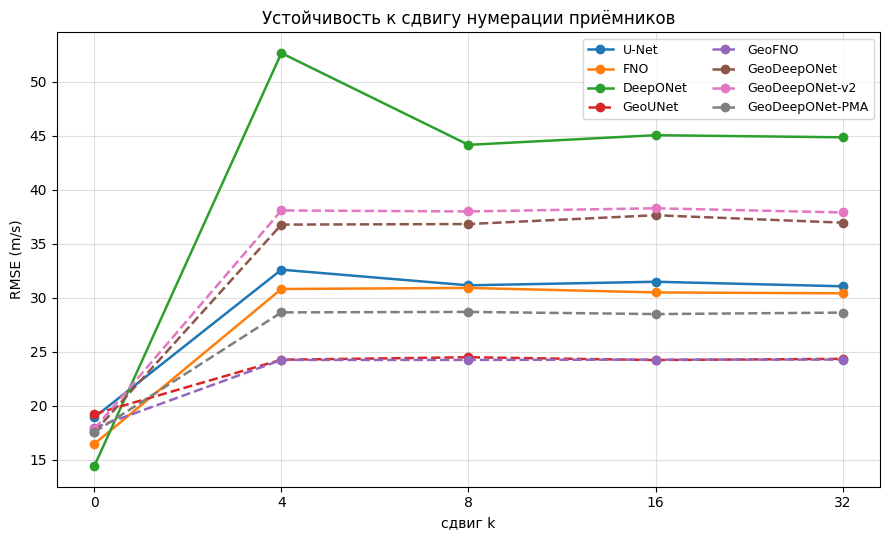

saved 25d results


In [40]:
def plot_sweep_25d(results, levels, title, xlabel, fname):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for name in MODEL_ORDER:
        ys = [results[lv][name] for lv in levels]
        ls = "--" if is_geo(name) else "-"
        ax.plot(range(len(levels)), ys, marker="o", linestyle=ls,
                label=name, linewidth=1.8, markersize=6)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels])
    ax.set_xlabel(xlabel); ax.set_ylabel("RMSE (m/s)")
    ax.set_title(title); ax.grid(True, alpha=0.4); ax.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.savefig(OUT_DIR / fname, dpi=130, bbox_inches="tight")
    plt.show()

plot_sweep_25d(phase_results,  PHASE_LEVELS,  "Устойчивость к фазовому джиттеру",        "sigma (рад)",  "plot_phase_jitter.png")
plot_sweep_25d(sector_results, SECTOR_LEVELS, "Устойчивость к выпадению сектора приёмников", "доля кольца", "plot_sector_dropout.png")
plot_sweep_25d(shift_results,  SHIFT_LEVELS,  "Устойчивость к сдвигу нумерации приёмников",  "сдвиг k",     "plot_receiver_shift.png")

# сохранить числа
def _str(d): return {str(k): (_str(v) if isinstance(v, dict) else v) for k, v in d.items()}
with open(OUT_DIR / "robustness_25d_results.json", "w") as f:
    json.dump({"baseline": baseline_rmse_25d,
               "phase_jitter": _str(phase_deg),
               "sector_dropout": _str(sector_deg),
               "receiver_shift": _str(shift_deg)}, f, indent=2)
print("saved 25d results")